# Exoplanet EDA — exoplanet.eu katalog
### Dataset: `exoplanet.eu_catalog_24-06-26_21_54_46.csv`
Izvor: https://exoplanet.eu/catalog/

**Cilj:** Upoznavanje sa datasetom — dimenzije, tipovi podataka, nedostajuće vrednosti, distribucije ključnih promenljivih, vizualizacije i početni zaključci.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# Globalni stil
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

CSV_PATH = r"C:\Users\Dell\Downloads\exoplanet.eu_catalog_24-06-26_21_54_46.csv"
df = pd.read_csv(CSV_PATH)

print(f"Učitano  {df.shape[0]:,} redova  ×  {df.shape[1]} kolona")

Učitano  6,429 redova  ×  98 kolona


---
## 1. Pregled structure dataseta

In [2]:
print("=== dtypes i broj non-null vrednosti ===")
df.info(verbose=True, show_counts=True)

=== dtypes i broj non-null vrednosti ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6429 entries, 0 to 6428
Data columns (total 98 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        6429 non-null   object 
 1   planet_status               6429 non-null   object 
 2   mass                        2353 non-null   float64
 3   mass_error_min              3094 non-null   float64
 4   mass_error_max              3094 non-null   float64
 5   mass_sini                   1268 non-null   float64
 6   mass_sini_error_min         1109 non-null   float64
 7   mass_sini_error_max         1109 non-null   float64
 8   radius                      4904 non-null   float64
 9   radius_error_min            4337 non-null   float64
 10  radius_error_max            4337 non-null   float64
 11  orbital_period              6078 non-null   float64
 12  orbital_period_error_min    5409 non-null   float

In [3]:
# Grupisanje kolona po kategorijama
planet_cols = ["name", "planet_status", "mass", "mass_sini", "radius",
               "orbital_period", "semi_major_axis", "eccentricity",
               "inclination", "temp_calculated", "temp_measured",
               "geometric_albedo", "log_g", "discovered", "detection_type",
               "mass_measurement_type", "radius_measurement_type", "molecules"]

star_cols   = ["star_name", "ra", "dec", "star_distance", "star_metallicity",
               "star_mass", "star_radius", "star_sp_type", "star_age",
               "star_teff", "mag_v", "mag_j", "mag_h", "mag_k"]

error_cols  = [c for c in df.columns if "_error_" in c]
timing_cols = [c for c in df.columns if c.startswith("t") and c not in planet_cols + star_cols]

print(f"Kolone vezane za planet : {len(planet_cols)}")
print(f"Kolone vezane za zvezdu : {len(star_cols)}")
print(f"Error/uncertainty kolone: {len(error_cols)}")
print(f"Timing kolone           : {len(timing_cols)}")
print(f"Ukupno                  : {df.shape[1]}")

Kolone vezane za planet : 18
Kolone vezane za zvezdu : 14
Error/uncertainty kolone: 48
Timing kolone           : 17
Ukupno                  : 98


In [4]:
df.head(3)

,name,planet_status,mass,mass_error_min,mass_error_max,mass_sini,mass_sini_error_min,mass_sini_error_max,radius,radius_error_min,...,star_sp_type,star_age,star_age_error_min,star_age_error_max,star_teff,star_teff_error_min,star_teff_error_max,star_detected_disc,star_magnetic_field,star_alternate_names
0,109 Psc b,Confirmed,6.800,0.300,0.900,6.383,0.078,0.078,1.152,NaN,...,G5 IV,6.9,0.6,0.6,5600.0,80.000,80.000,NaN,NaN,HD 10697
1,112 Psc b,Confirmed,NaN,0.005,0.004,0.033,0.005,0.004,NaN,NaN,...,G0IV,NaN,NaN,NaN,5986.0,105.437,105.437,NaN,NaN,HD 12235
2,112 Psc c,Confirmed,9.866,1.781,3.190,NaN,NaN,NaN,NaN,NaN,...,G0IV,NaN,NaN,NaN,5986.0,105.437,105.437,NaN,NaN,HD 12235


In [5]:
print("=== Opisna statistika (numeričke kolone) ===")
num_cols = ["mass", "radius", "orbital_period", "semi_major_axis",
            "eccentricity", "inclination", "temp_calculated",
            "star_distance", "star_mass", "star_radius",
            "star_metallicity", "star_teff", "star_age"]
df[num_cols].describe().T.round(3)

=== Opisna statistika (numeričke kolone) ===


,count,mean,std,min,25%,50%,75%,max
mass,2353.0,1.526,2.644,0.000,0.030,0.380,1.487,12.934
radius,4904.0,0.410,0.443,0.000,0.147,0.222,0.413,6.900
orbital_period,6078.0,1165.731,42023.187,0.024,4.226,10.503,36.444,2722900.000
semi_major_axis,4799.0,30.485,1226.185,0.001,0.051,0.102,0.410,80679.000
eccentricity,3150.0,0.129,0.184,0.000,0.000,0.058,0.190,3.155
inclination,2553.0,86.783,12.769,-2.000,86.450,88.490,89.460,279.000
temp_calculated,2312.0,934.202,497.035,56.000,560.750,834.900,1228.725,3921.000
star_distance,6189.0,703.668,1230.317,1.295,101.900,366.200,816.220,8900.000
star_mass,6063.0,0.930,0.336,0.011,0.770,0.940,1.090,5.500
star_radius,5794.0,1.365,2.619,0.000,0.770,0.960,1.250,51.100


---
## 2. Analiza nedostajućih vrednosti (NaN)

In [6]:
nan_df = pd.DataFrame({
    "missing": df.isnull().sum(),
    "pct":     df.isnull().mean() * 100
}).sort_values("pct", ascending=False)

print("Kolone bez ijednog NaN-a:")
print(nan_df[nan_df["missing"] == 0].index.tolist())
print()
print("Kolone sa > 95% NaN-ova:")
print(nan_df[nan_df["pct"] > 95].index.tolist())

Kolone bez ijednog NaN-a:
['planet_status', 'discovered', 'updated', 'name', 'detection_type', 'publication', 'ra', 'dec', 'star_name']

Kolone sa > 95% NaN-ova:
['hot_point_lon', 'star_magnetic_field', 'geometric_albedo_error_min', 'geometric_albedo_error_max', 'geometric_albedo', 'log_g', 'tzero_vr_error_max', 'tzero_vr_error_min', 'tzero_vr', 'temp_measured', 'tzero_tr_sec_error_max', 'tzero_tr_sec_error_min', 'tzero_tr_sec', 'star_detected_disc', 'molecules', 'lambda_angle', 'lambda_angle_error_min', 'lambda_angle_error_max']


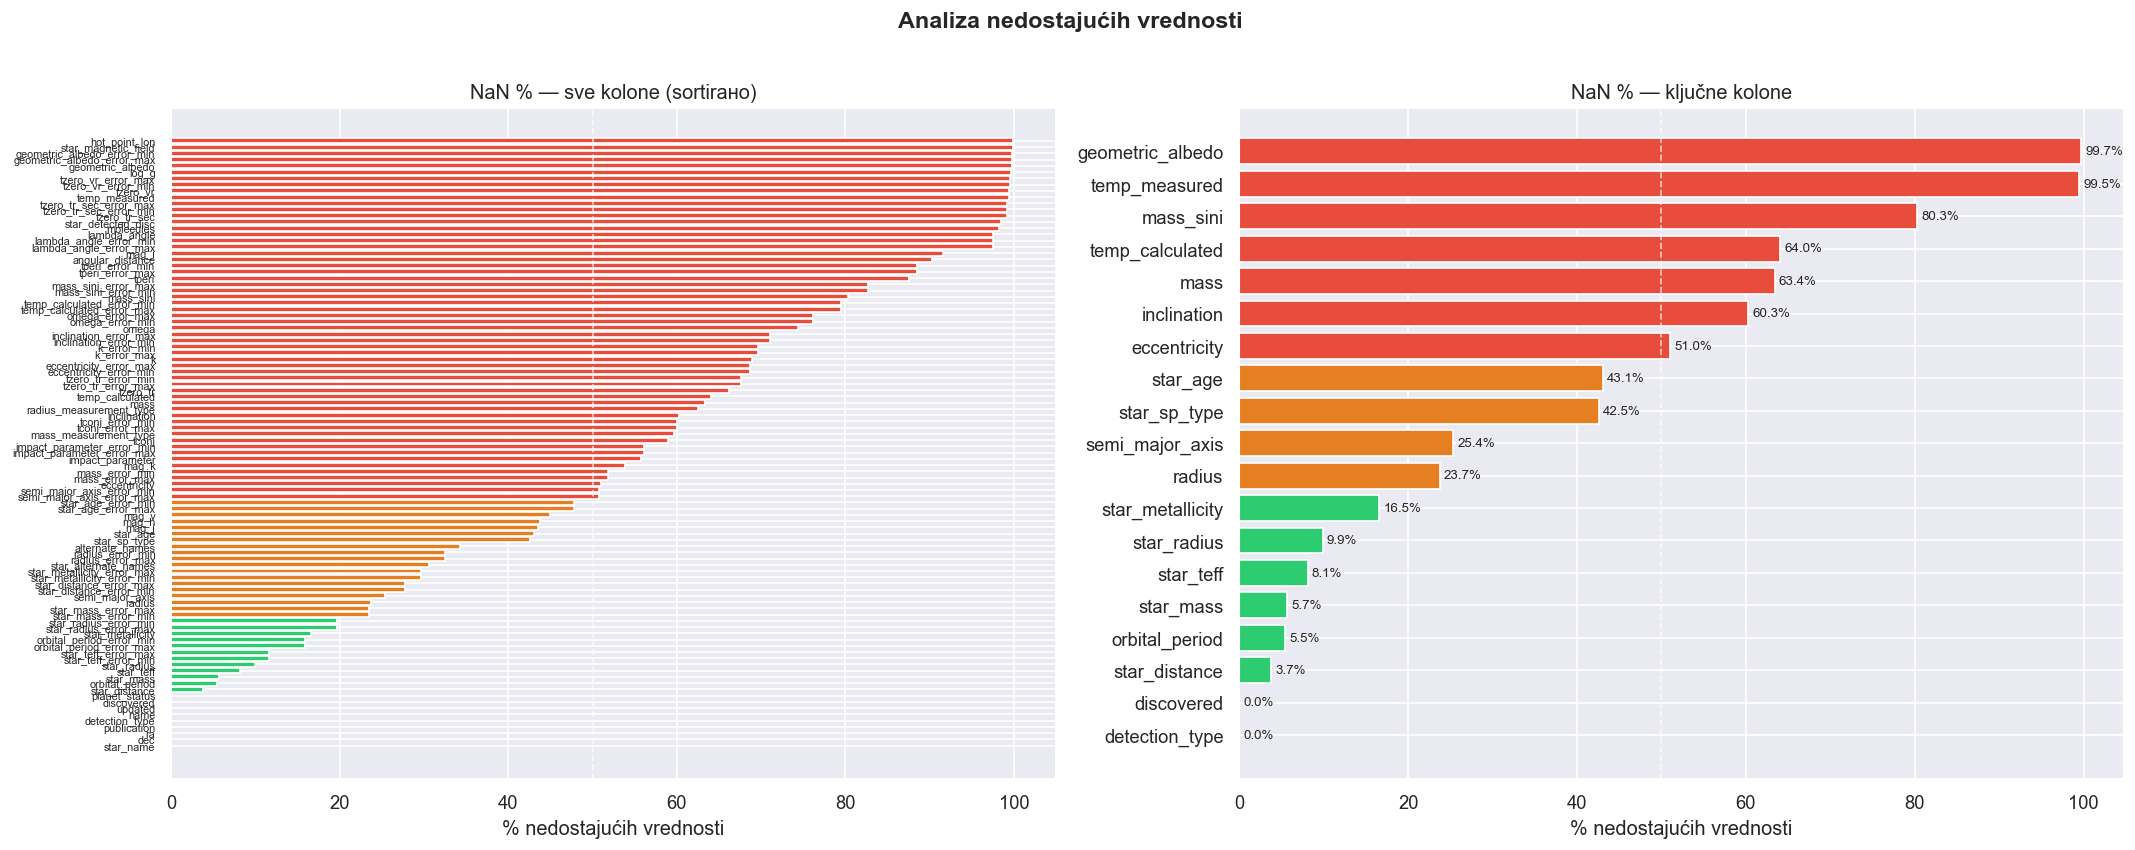

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Levi grafik — sve kolone
colors = ["#e74c3c" if p > 50 else "#e67e22" if p > 20 else "#2ecc71"
          for p in nan_df["pct"]]
axes[0].barh(nan_df.index, nan_df["pct"], color=colors)
axes[0].axvline(50, color="white", lw=1, ls="--", alpha=0.7)
axes[0].set_xlabel("% nedostajućih vrednosti")
axes[0].set_title("NaN % — sve kolone (sortirано)")
axes[0].invert_yaxis()
axes[0].tick_params(axis="y", labelsize=6.5)

# Desni grafik — samo ključne kolone
key_cols = ["mass", "mass_sini", "radius", "orbital_period", "semi_major_axis",
            "eccentricity", "inclination", "temp_calculated", "temp_measured",
            "geometric_albedo", "star_distance", "star_metallicity",
            "star_mass", "star_radius", "star_sp_type", "star_age", "star_teff",
            "detection_type", "discovered"]
key_nan = nan_df.loc[nan_df.index.isin(key_cols)].sort_values("pct", ascending=False)
bar_colors = ["#e74c3c" if p > 50 else "#e67e22" if p > 20 else "#2ecc71"
              for p in key_nan["pct"]]
axes[1].barh(key_nan.index, key_nan["pct"], color=bar_colors)
axes[1].axvline(50, color="white", lw=1, ls="--", alpha=0.7, label="50%")
for i, (val, col) in enumerate(zip(key_nan["pct"], key_nan.index)):
    axes[1].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)
axes[1].set_xlabel("% nedostajućih vrednosti")
axes[1].set_title("NaN % — ključne kolone")
axes[1].invert_yaxis()

plt.suptitle("Analiza nedostajućih vrednosti", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Metode detekcije egzoplaneta

detection_type
Primary Transit                         4784
Radial Velocity                         1069
Microlensing                             286
Radial Velocity, Astrometry               81
Imaging                                   53
Timing                                    52
TTV                                       32
Other                                     16
Astrometry                                15
Primary Transit, Radial Velocity           7
Radial Velocity, Primary Transit           7
Primary Transit, TTV                       6
Imaging, Astrometry                        3
Timing, Other                              2
Timing, Kinematic                          2
Kinematic                                  2
Imaging, Kinematic                         2
Other, Radial Velocity                     2
Radial Velocity, TTV                       2
Imaging, Other, Kinematic                  1
Radial Velocity, Astrometry, Imaging       1
Imaging, Other                          

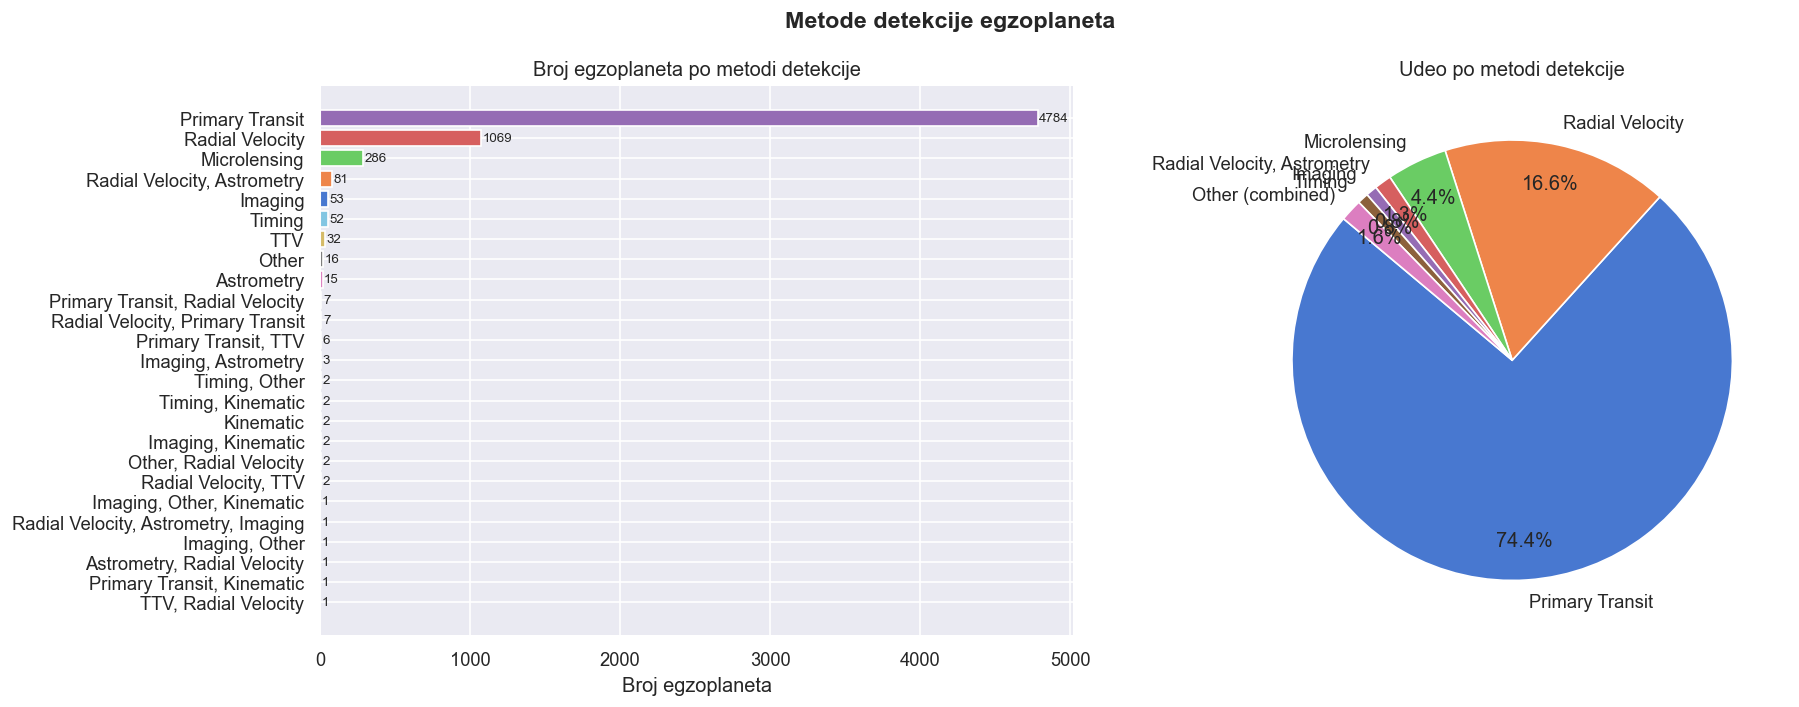

In [8]:
det_counts = df["detection_type"].value_counts()
print(det_counts.to_string())

# Grupisanje radi preglednosti pie-charta
TOP_N = 6
top = det_counts.head(TOP_N)
other = det_counts.iloc[TOP_N:].sum()
pie_data = pd.concat([top, pd.Series({"Other (combined)": other})])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].barh(det_counts.index[::-1], det_counts.values[::-1],
             color=sns.color_palette("muted", len(det_counts)))
axes[0].set_xlabel("Broj egzoplaneta")
axes[0].set_title("Broj egzoplaneta po metodi detekcije")
for i, v in enumerate(det_counts.values[::-1]):
    axes[0].text(v + 10, i, str(v), va="center", fontsize=8)

# Pie chart
wedge_colors = sns.color_palette("muted", len(pie_data))
axes[1].pie(pie_data.values, labels=pie_data.index,
            autopct="%1.1f%%", colors=wedge_colors,
            startangle=140, pctdistance=0.82)
axes[1].set_title("Udeo po metodi detekcije")

plt.suptitle("Metode detekcije egzoplaneta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Otkrivanje kroz vreme

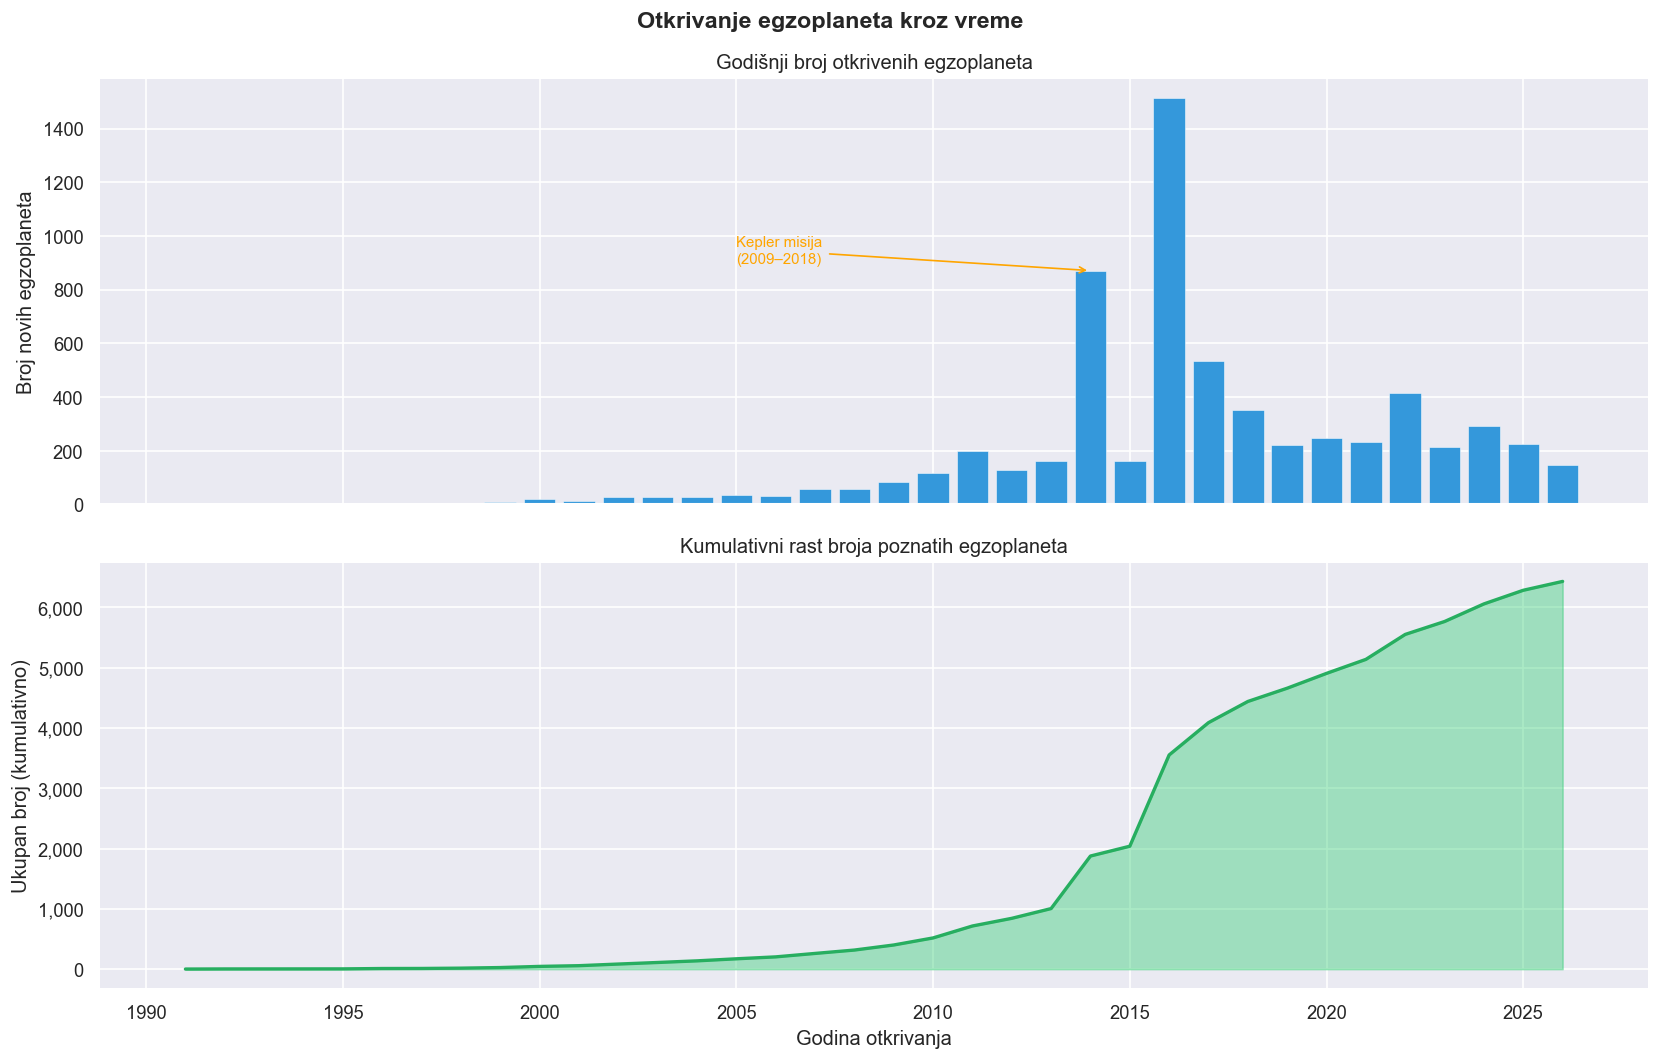

In [9]:
disc = df.dropna(subset=["discovered"]).copy()
disc["discovered"] = disc["discovered"].astype(int)

by_year = disc.groupby("discovered").size().reset_index(name="count")
by_year["cumulative"] = by_year["count"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Godišnje otkrivanje
axes[0].bar(by_year["discovered"], by_year["count"],
            color="#3498db", edgecolor="white", linewidth=0.3)
axes[0].set_ylabel("Broj novih egzoplaneta")
axes[0].set_title("Godišnji broj otkrivenih egzoplaneta")
axes[0].annotate("Kepler misija\n(2009–2018)", xy=(2014, by_year.loc[by_year["discovered"]==2014,"count"].values[0]),
                 xytext=(2005, 900), arrowprops=dict(arrowstyle="->", color="orange"),
                 fontsize=9, color="orange")

# Kumulativna kriva
axes[1].fill_between(by_year["discovered"], by_year["cumulative"], alpha=0.4, color="#2ecc71")
axes[1].plot(by_year["discovered"], by_year["cumulative"], color="#27ae60", lw=2)
axes[1].set_ylabel("Ukupan broj (kumulativno)")
axes[1].set_xlabel("Godina otkrivanja")
axes[1].set_title("Kumulativni rast broja poznatih egzoplaneta")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Otkrivanje egzoplaneta kroz vreme", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

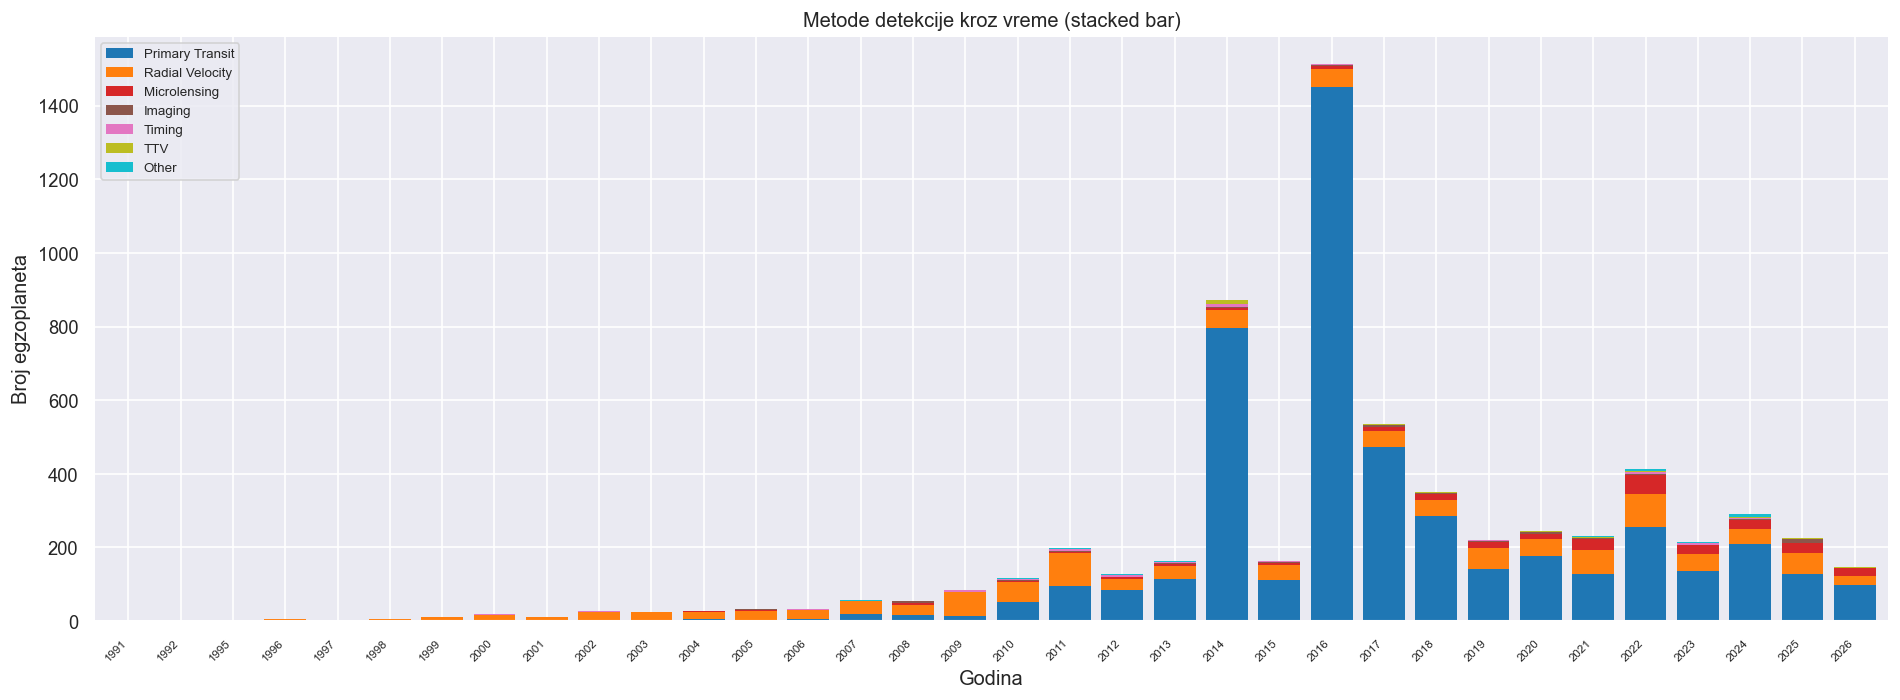

In [10]:
# Metoda detekcije kroz vreme — stacked bar
main_methods = ["Primary Transit", "Radial Velocity", "Microlensing",
                "Imaging", "Timing", "TTV"]

def simplify_method(m):
    for mm in main_methods:
        if mm.lower() in str(m).lower():
            return mm
    return "Other"

disc["det_simple"] = disc["detection_type"].apply(simplify_method)
pivot = disc.groupby(["discovered", "det_simple"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=main_methods + ["Other"], fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(16, 6),
           colormap="tab10", edgecolor="none", width=0.8)
plt.xlabel("Godina")
plt.ylabel("Broj egzoplaneta")
plt.title("Metode detekcije kroz vreme (stacked bar)")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

---
## 5. Fizičke osobine egzoplaneta — masa i radijus

C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\2063270196.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\2063270196.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\2063270196.py:40: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\p

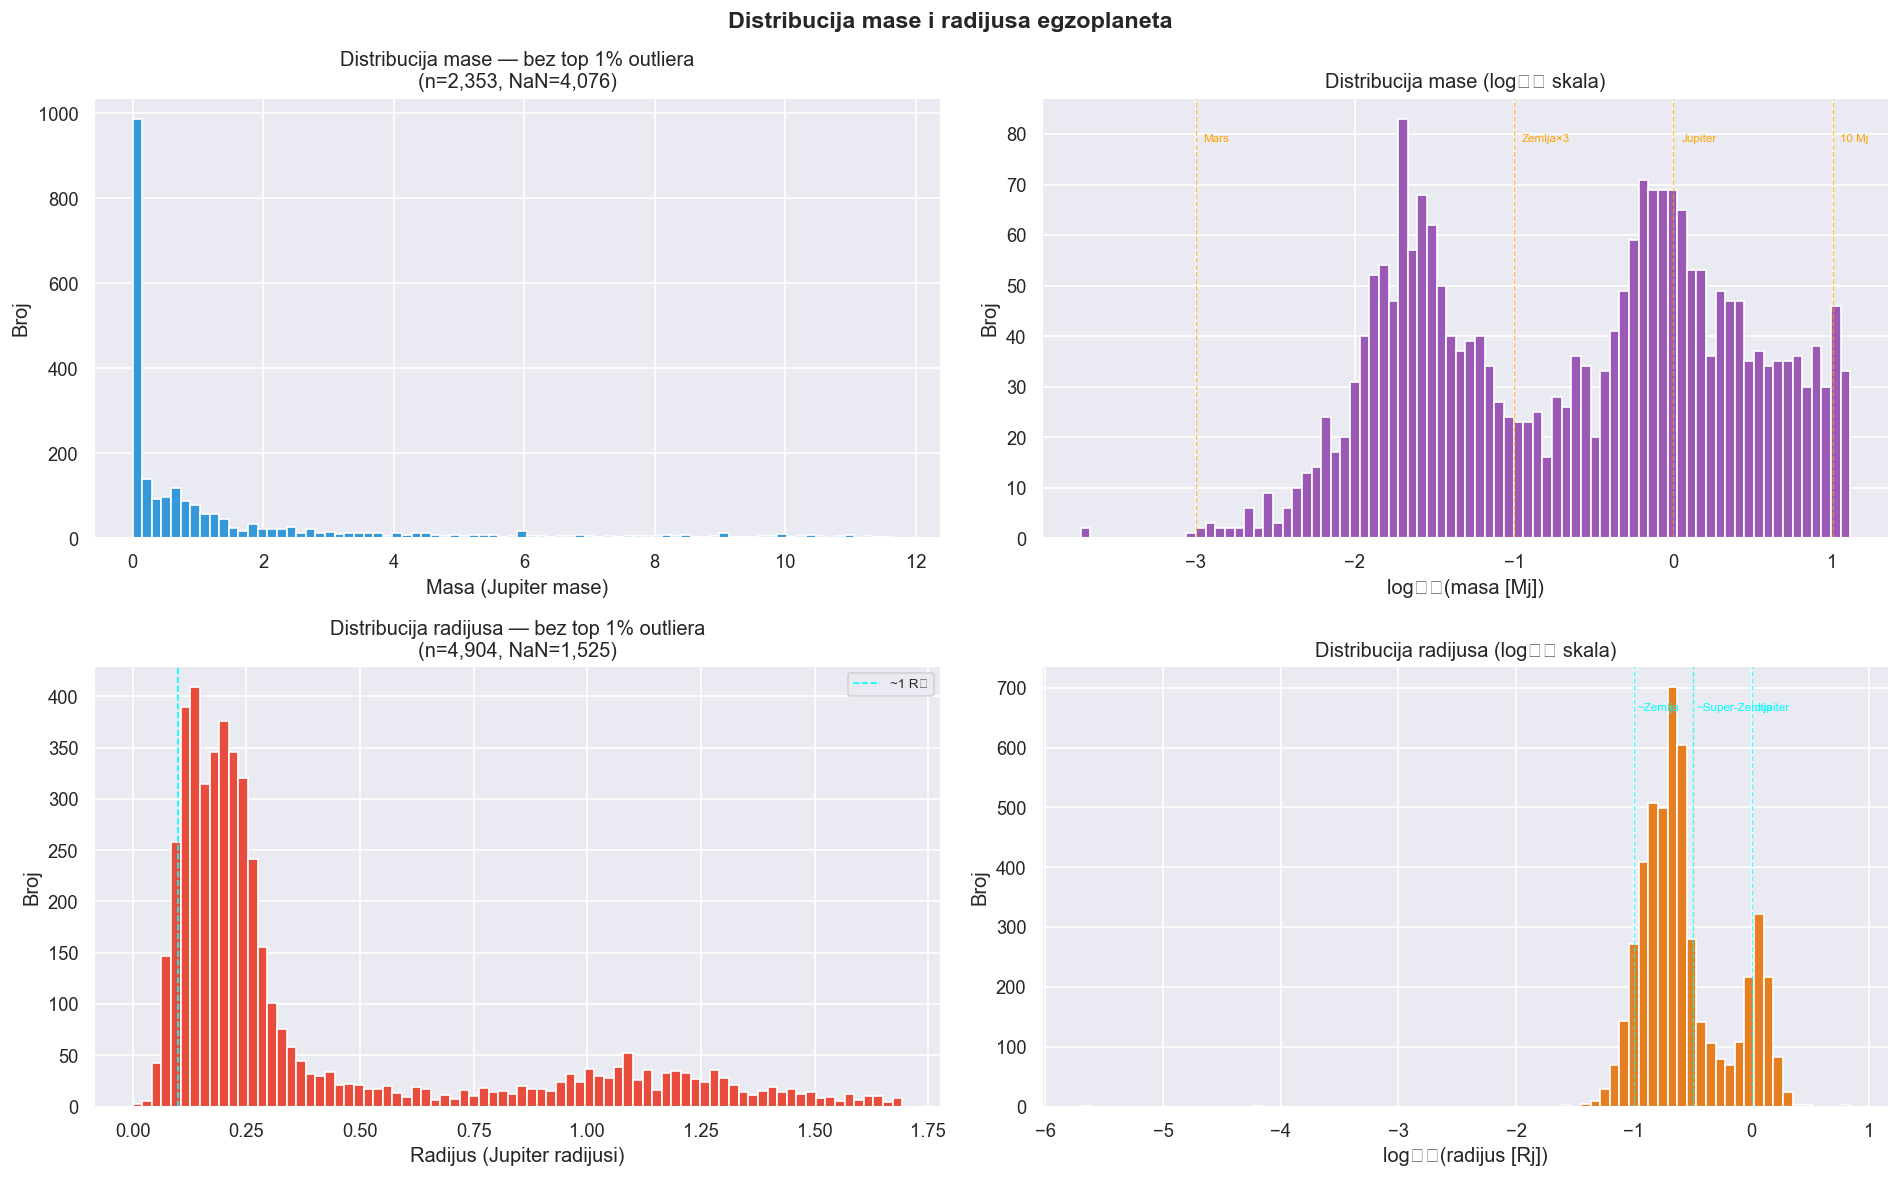

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Masa — linearna skala (bez ekstremnih outliera)
mass_data = df["mass"].dropna()
mass_clip = mass_data[mass_data < mass_data.quantile(0.99)]
axes[0, 0].hist(mass_clip, bins=80, color="#3498db", edgecolor="white", lw=0.3)
axes[0, 0].set_xlabel("Masa (Jupiter mase)")
axes[0, 0].set_ylabel("Broj")
axes[0, 0].set_title(f"Distribucija mase — bez top 1% outliera\n(n={len(mass_data):,}, NaN={df['mass'].isna().sum():,})")

# Masa — log skala
axes[0, 1].hist(np.log10(mass_data[mass_data > 0]), bins=80, color="#9b59b6", edgecolor="white", lw=0.3)
axes[0, 1].set_xlabel("log₁₀(masa [Mj])")
axes[0, 1].set_ylabel("Broj")
axes[0, 1].set_title("Distribucija mase (log₁₀ skala)")
for x, lbl in [(-3, "Mars"), (-1, "Zemlja×3"), (0, "Jupiter"), (1, "10 Mj")]:
    axes[0, 1].axvline(x, color="orange", ls="--", lw=0.8, alpha=0.7)
    axes[0, 1].text(x + 0.05, axes[0, 1].get_ylim()[1] * 0.9, lbl, fontsize=7, color="orange")

# Radijus — linearna skala
rad_data = df["radius"].dropna()
rad_clip = rad_data[rad_data < rad_data.quantile(0.99)]
axes[1, 0].hist(rad_clip, bins=80, color="#e74c3c", edgecolor="white", lw=0.3)
axes[1, 0].set_xlabel("Radijus (Jupiter radijusi)")
axes[1, 0].set_ylabel("Broj")
axes[1, 0].set_title(f"Distribucija radijusa — bez top 1% outliera\n(n={len(rad_data):,}, NaN={df['radius'].isna().sum():,})")
axes[1, 0].axvline(0.1, color="cyan", ls="--", lw=1, label="~1 R⊕")
axes[1, 0].legend(fontsize=8)

# Radijus — log skala
axes[1, 1].hist(np.log10(rad_data[rad_data > 0]), bins=80, color="#e67e22", edgecolor="white", lw=0.3)
axes[1, 1].set_xlabel("log₁₀(radijus [Rj])")
axes[1, 1].set_ylabel("Broj")
axes[1, 1].set_title("Distribucija radijusa (log₁₀ skala)")
for x, lbl in [(-1, "~Zemlja"), (-0.5, "~Super-Zemlja"), (0, "Jupiter")]:
    axes[1, 1].axvline(x, color="cyan", ls="--", lw=0.8, alpha=0.7)
    axes[1, 1].text(x + 0.03, axes[1, 1].get_ylim()[1] * 0.9, lbl, fontsize=7, color="cyan")

plt.suptitle("Distribucija mase i radijusa egzoplaneta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

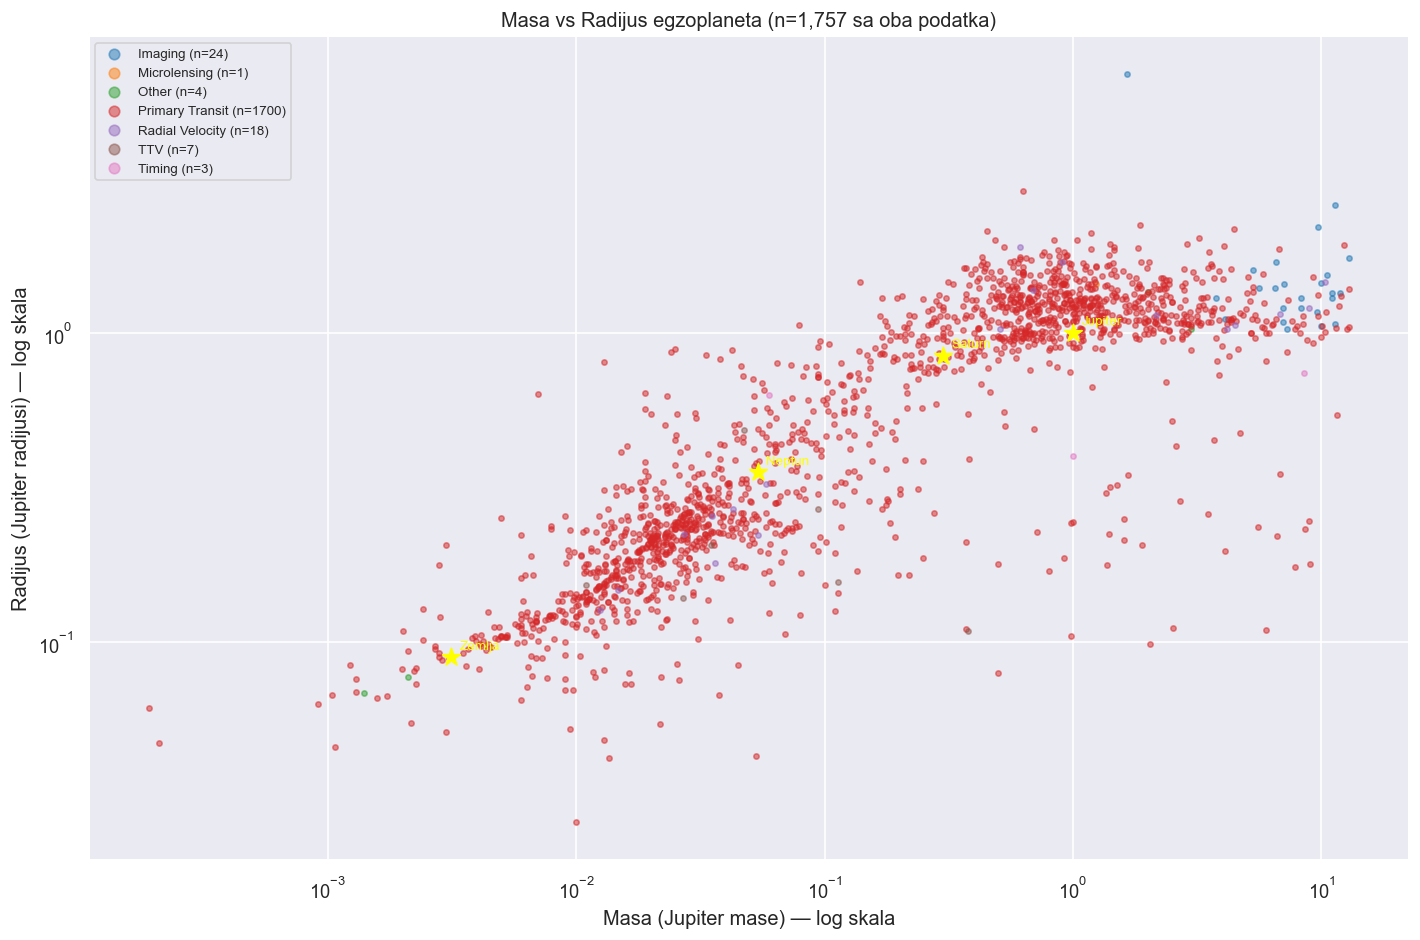


Broj egzoplaneta sa poznatom i masom i radijusom: 1,757
Samo masa poznata: 596
Samo radijus poznat: 3,147


In [12]:
# Masa vs Radijus — "Mass-Radius diagram" (klasičan astrofizički dijagram)
mr = df[["mass", "radius", "detection_type"]].dropna(subset=["mass", "radius"]).copy()
mr["det_simple"] = mr["detection_type"].apply(simplify_method)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("tab10", len(mr["det_simple"].unique()))
for color, (method, grp) in zip(palette, mr.groupby("det_simple")):
    ax.scatter(grp["mass"], grp["radius"], s=10, alpha=0.5,
               label=f"{method} (n={len(grp)})", color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Masa (Jupiter mase) — log skala")
ax.set_ylabel("Radijus (Jupiter radijusi) — log skala")
ax.set_title(f"Masa vs Radijus egzoplaneta (n={len(mr):,} sa oba podatka)")

# Referentne tačke
ref_points = {"Zemlja": (0.00315, 0.0892), "Jupiter": (1, 1),
              "Neptun": (0.054, 0.354), "Saturn": (0.299, 0.843)}
for name_p, (mx, rx) in ref_points.items():
    ax.scatter([mx], [rx], s=120, marker="*", color="yellow", zorder=5)
    ax.annotate(name_p, (mx, rx), textcoords="offset points",
                xytext=(5, 5), fontsize=8, color="yellow")

ax.legend(loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

print(f"\nBroj egzoplaneta sa poznatom i masom i radijusom: {len(mr):,}")
print(f"Samo masa poznata: {df['mass'].notna().sum() - len(mr):,}")
print(f"Samo radijus poznat: {df['radius'].notna().sum() - len(mr):,}")

---
## 6. Orbitalne osobine

C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\4290622713.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\4290622713.py:36: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


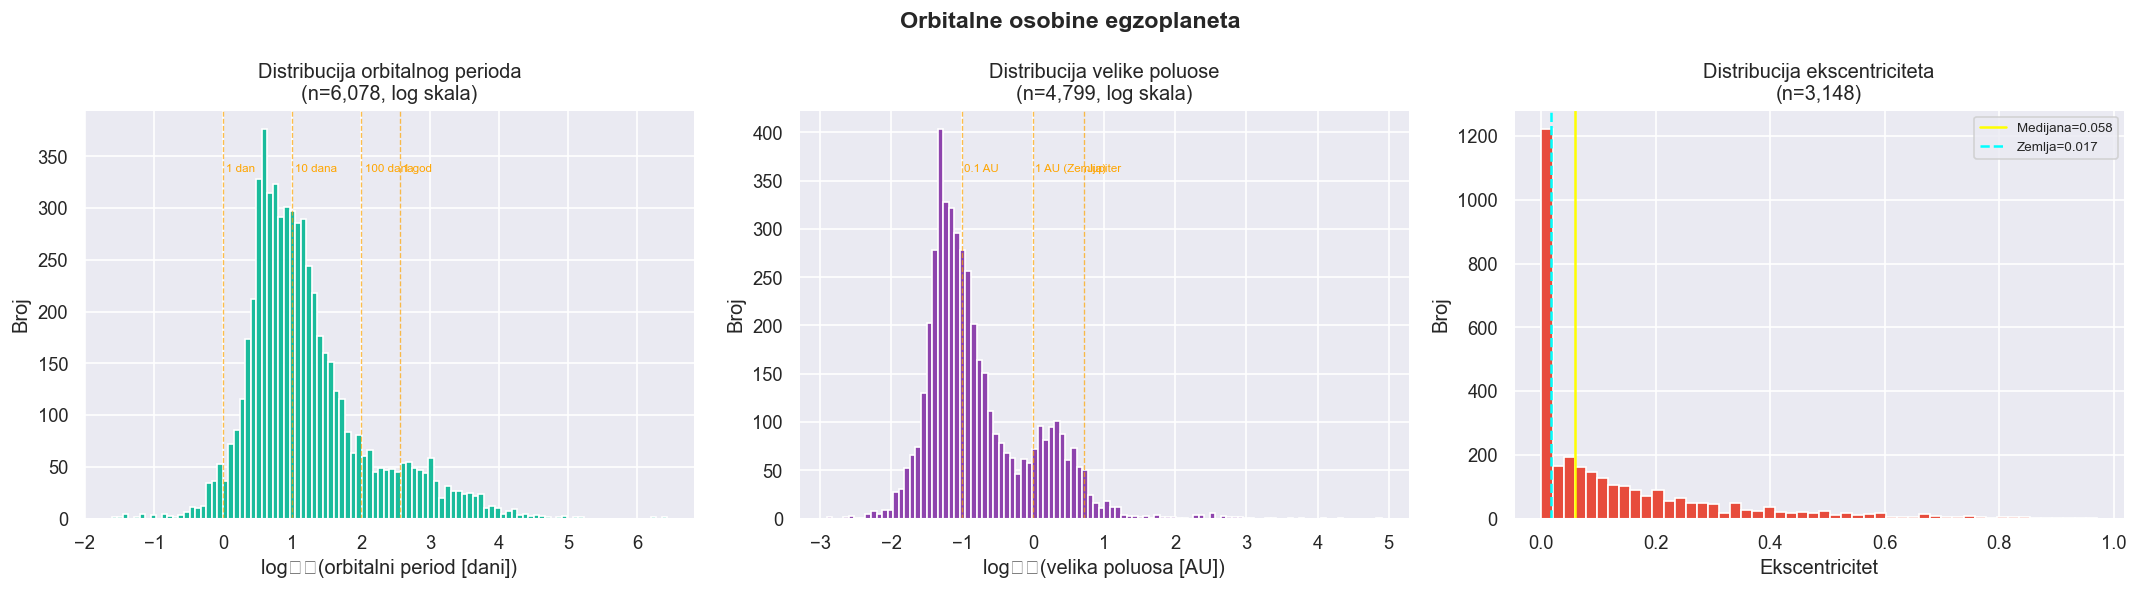

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Orbitalni period
op = df["orbital_period"].dropna()
op_days = op[op < op.quantile(0.995)]
axes[0].hist(np.log10(op[op > 0]), bins=100, color="#1abc9c", edgecolor="white", lw=0.2)
axes[0].set_xlabel("log₁₀(orbitalni period [dani])")
axes[0].set_ylabel("Broj")
axes[0].set_title(f"Distribucija orbitalnog perioda\n(n={len(op):,}, log skala)")
for val, lbl in [(0, "1 dan"), (1, "10 dana"), (2, "100 dana"), (np.log10(365), "1 god")]:
    axes[0].axvline(val, color="orange", ls="--", lw=0.8, alpha=0.7)
    axes[0].text(val + 0.05, axes[0].get_ylim()[1] * 0.85, lbl, fontsize=7, color="orange")

# Velika poluosa
sma = df["semi_major_axis"].dropna()
axes[1].hist(np.log10(sma[sma > 0]), bins=100, color="#8e44ad", edgecolor="white", lw=0.2)
axes[1].set_xlabel("log₁₀(velika poluosa [AU])")
axes[1].set_ylabel("Broj")
axes[1].set_title(f"Distribucija velike poluose\n(n={len(sma):,}, log skala)")
for val, lbl in [(np.log10(0.1), "0.1 AU"), (0, "1 AU (Zemlja)"), (np.log10(5.2), "Jupiter")]:
    axes[1].axvline(val, color="orange", ls="--", lw=0.8, alpha=0.7)
    axes[1].text(val + 0.03, axes[1].get_ylim()[1] * 0.85, lbl, fontsize=7, color="orange")

# Ekscentricitet
ecc = df["eccentricity"].dropna()
ecc = ecc[(ecc >= 0) & (ecc <= 1)]
axes[2].hist(ecc, bins=50, color="#e74c3c", edgecolor="white", lw=0.3)
axes[2].set_xlabel("Ekscentricitet")
axes[2].set_ylabel("Broj")
axes[2].set_title(f"Distribucija ekscentriciteta\n(n={len(ecc):,})")
axes[2].axvline(ecc.median(), color="yellow", lw=1.5, label=f"Medijana={ecc.median():.3f}")
axes[2].axvline(0.0167, color="cyan", lw=1.5, ls="--", label="Zemlja=0.017")
axes[2].legend(fontsize=8)

plt.suptitle("Orbitalne osobine egzoplaneta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\489723481.py:34: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


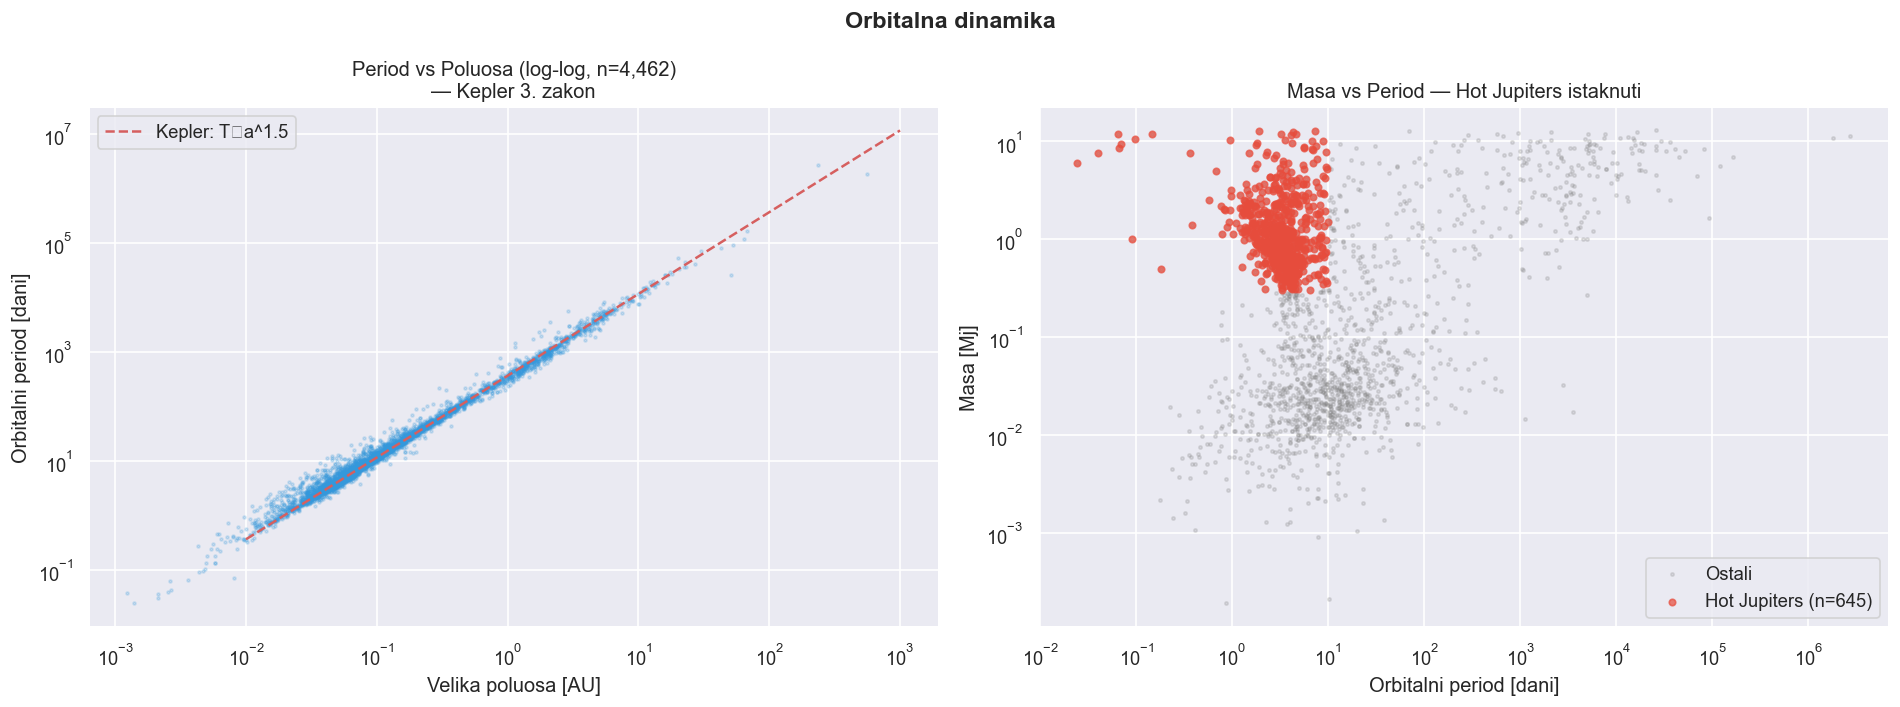

Hot Jupiters (period<10d, masa>0.3Mj): 645 egzoplaneta (10.0%)


In [14]:
# Period vs Poluosa — Kepler's 3rd law check (T² ∝ a³)
pa = df[["orbital_period", "semi_major_axis"]].dropna()
pa = pa[(pa["orbital_period"] > 0) & (pa["semi_major_axis"] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(pa["semi_major_axis"], pa["orbital_period"],
                s=3, alpha=0.2, color="#3498db")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Velika poluosa [AU]")
axes[0].set_ylabel("Orbitalni period [dani]")
axes[0].set_title(f"Period vs Poluosa (log-log, n={len(pa):,})\n— Kepler 3. zakon")
# Teorijska linija T[god] = a^1.5 => T[dan] = a^1.5 * 365.25
a_range = np.logspace(-2, 3, 200)
t_kepler = a_range**1.5 * 365.25
axes[0].plot(a_range, t_kepler, "r--", lw=1.5, label="Kepler: T∝a^1.5")
axes[0].legend()

# Hot Jupiters: period < 10 dana, masa > 0.3 Mj
hj = df[(df["orbital_period"] < 10) & (df["mass"] > 0.3)]
all_w_period_mass = df[["orbital_period", "mass"]].dropna()
axes[1].scatter(all_w_period_mass["orbital_period"],
                all_w_period_mass["mass"],
                s=4, alpha=0.2, color="gray", label="Ostali")
axes[1].scatter(hj["orbital_period"], hj["mass"],
                s=15, alpha=0.7, color="#e74c3c", label=f"Hot Jupiters (n={len(hj)})")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Orbitalni period [dani]")
axes[1].set_ylabel("Masa [Mj]")
axes[1].set_title("Masa vs Period — Hot Jupiters istaknuti")
axes[1].legend()

plt.suptitle("Orbitalna dinamika", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Hot Jupiters (period<10d, masa>0.3Mj): {len(hj):,} egzoplaneta ({len(hj)/len(df)*100:.1f}%)")

---
## 7. Temperatura egzoplaneta

Planete u habitabilnoj zoni po temperaturi (200-350K): 160


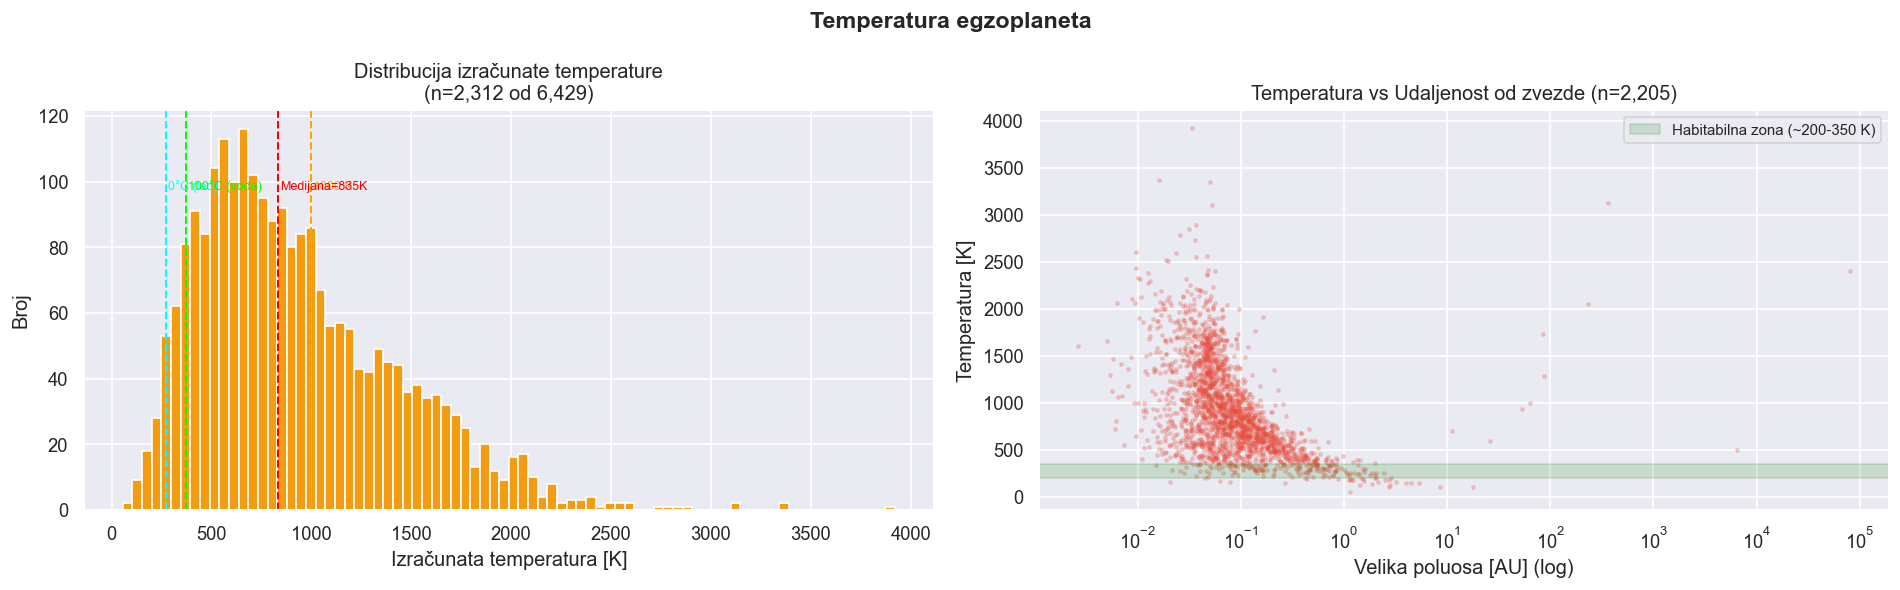

In [15]:
temp = df["temp_calculated"].dropna()
temp = temp[temp > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(temp, bins=80, color="#f39c12", edgecolor="white", lw=0.3)
axes[0].set_xlabel("Izračunata temperatura [K]")
axes[0].set_ylabel("Broj")
axes[0].set_title(f"Distribucija izračunate temperature\n(n={len(temp):,} od {len(df):,})")
for val, lbl, col in [(273, "0°C (led)", "cyan"), (373, "100°C (voda)", "lime"),
                      (1000, "1000 K", "orange"), (temp.median(), f"Medijana={temp.median():.0f}K", "red")]:
    axes[0].axvline(val, color=col, lw=1.2, ls="--")
    axes[0].text(val + 10, axes[0].get_ylim()[1] * 0.8, lbl, fontsize=7.5, color=col)

# Temperatura vs Poluosa — "habitability zone" ilustracija
ts = df[["temp_calculated", "semi_major_axis"]].dropna()
ts = ts[(ts["temp_calculated"] > 0) & (ts["semi_major_axis"] > 0)]
axes[1].scatter(ts["semi_major_axis"], ts["temp_calculated"],
                s=4, alpha=0.2, color="#e74c3c")
# "Habitabilna zona" ~200-350 K
axes[1].axhspan(200, 350, alpha=0.15, color="green", label="Habitabilna zona (~200-350 K)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Velika poluosa [AU] (log)")
axes[1].set_ylabel("Temperatura [K]")
axes[1].set_title(f"Temperatura vs Udaljenost od zvezde (n={len(ts):,})")
axes[1].legend(fontsize=9)

hz_count = len(df[(df["temp_calculated"] >= 200) & (df["temp_calculated"] <= 350)])
print(f"Planete u habitabilnoj zoni po temperaturi (200-350K): {hz_count}")

plt.suptitle("Temperatura egzoplaneta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Osobine zvezda domaćina

Zvezde bogatije od Sunca ([Fe/H]>0): 2,720 (50.7%)


C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\3454088114.py:64: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


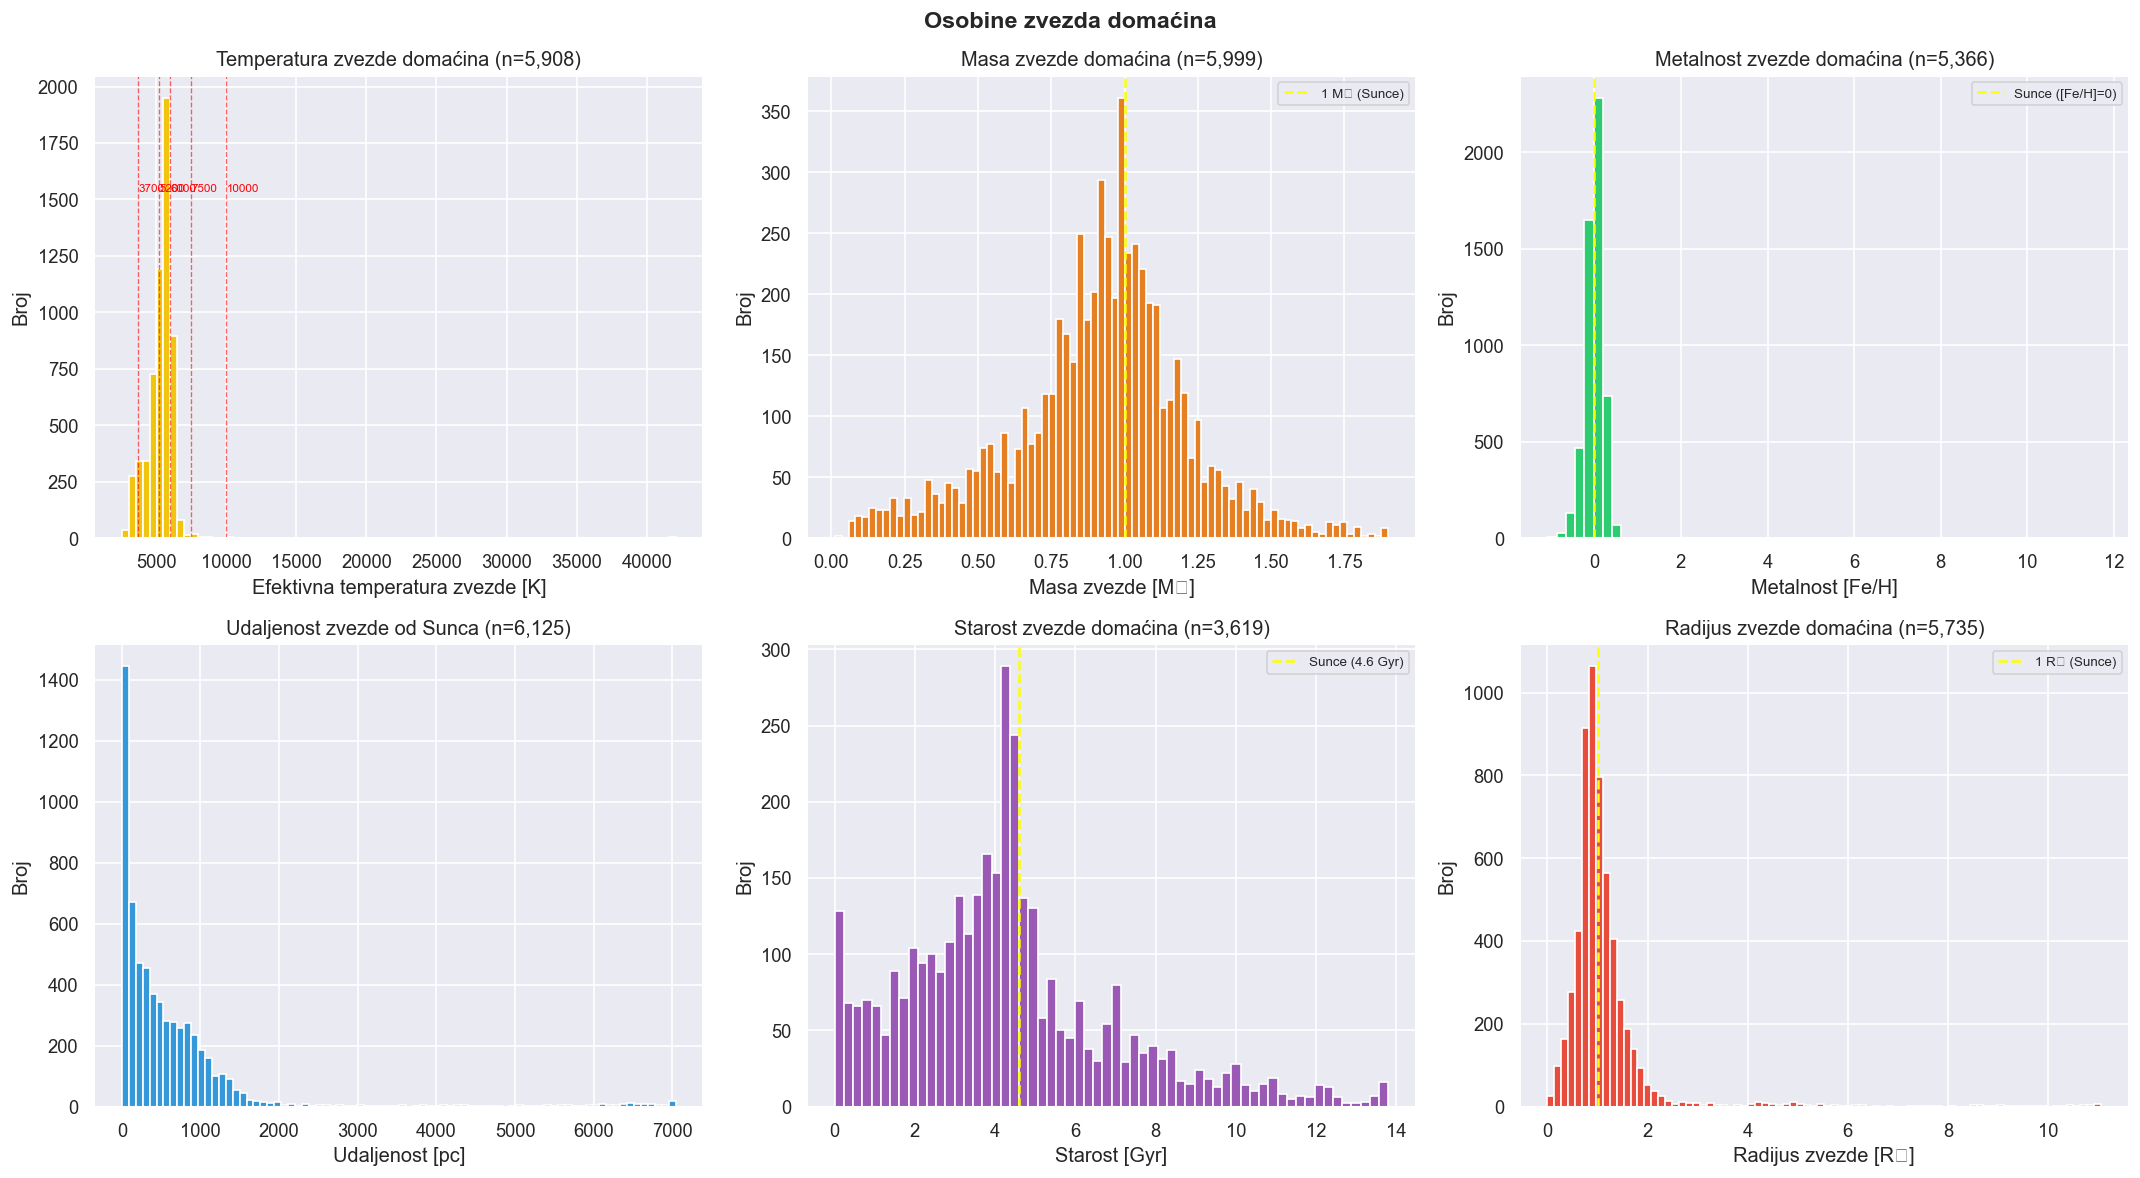

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Efektivna temperatura zvezde (HR dijagram proxy)
teff = df["star_teff"].dropna()
teff = teff[(teff > 1000) & (teff < 50000)]
axes[0, 0].hist(teff, bins=80, color="#f1c40f", edgecolor="white", lw=0.2)
axes[0, 0].set_xlabel("Efektivna temperatura zvezde [K]")
axes[0, 0].set_ylabel("Broj")
axes[0, 0].set_title(f"Temperatura zvezde domaćina (n={len(teff):,})")
sp_bounds = {"M": 3700, "K": 5200, "G": 6000, "F": 7500, "A": 10000}
for t, sp in sp_bounds.items():
    axes[0, 0].axvline(sp, color="red", lw=0.8, ls="--", alpha=0.6)
    axes[0, 0].text(sp + 50, axes[0, 0].get_ylim()[1] * 0.75, sp, fontsize=7, color="red")

# Masa zvezde
sm = df["star_mass"].dropna()
sm = sm[(sm > 0) & (sm < sm.quantile(0.99))]
axes[0, 1].hist(sm, bins=80, color="#e67e22", edgecolor="white", lw=0.2)
axes[0, 1].axvline(1.0, color="yellow", lw=1.5, ls="--", label="1 M☉ (Sunce)")
axes[0, 1].set_xlabel("Masa zvezde [M☉]")
axes[0, 1].set_ylabel("Broj")
axes[0, 1].set_title(f"Masa zvezde domaćina (n={len(sm):,})")
axes[0, 1].legend(fontsize=8)

# Metalnost zvezde
met = df["star_metallicity"].dropna()
axes[0, 2].hist(met, bins=60, color="#2ecc71", edgecolor="white", lw=0.2)
axes[0, 2].axvline(0, color="yellow", lw=1.5, ls="--", label="Sunce ([Fe/H]=0)")
axes[0, 2].set_xlabel("Metalnost [Fe/H]")
axes[0, 2].set_ylabel("Broj")
axes[0, 2].set_title(f"Metalnost zvezde domaćina (n={len(met):,})")
axes[0, 2].legend(fontsize=8)
print(f"Zvezde bogatije od Sunca ([Fe/H]>0): {(met>0).sum():,} ({(met>0).mean()*100:.1f}%)")

# Udaljenost zvezde
dist = df["star_distance"].dropna()
dist = dist[(dist > 0) & (dist < dist.quantile(0.99))]
axes[1, 0].hist(dist, bins=80, color="#3498db", edgecolor="white", lw=0.2)
axes[1, 0].set_xlabel("Udaljenost [pc]")
axes[1, 0].set_ylabel("Broj")
axes[1, 0].set_title(f"Udaljenost zvezde od Sunca (n={len(dist):,})")

# Starost zvezde
age = df["star_age"].dropna()
age = age[(age > 0) & (age < age.quantile(0.99))]
axes[1, 1].hist(age, bins=60, color="#9b59b6", edgecolor="white", lw=0.2)
axes[1, 1].axvline(4.6, color="yellow", lw=1.5, ls="--", label="Sunce (4.6 Gyr)")
axes[1, 1].set_xlabel("Starost [Gyr]")
axes[1, 1].set_ylabel("Broj")
axes[1, 1].set_title(f"Starost zvezde domaćina (n={len(age):,})")
axes[1, 1].legend(fontsize=8)

# Radijus zvezde
sr = df["star_radius"].dropna()
sr = sr[(sr > 0) & (sr < sr.quantile(0.99))]
axes[1, 2].hist(sr, bins=80, color="#e74c3c", edgecolor="white", lw=0.2)
axes[1, 2].axvline(1.0, color="yellow", lw=1.5, ls="--", label="1 R☉ (Sunce)")
axes[1, 2].set_xlabel("Radijus zvezde [R☉]")
axes[1, 2].set_ylabel("Broj")
axes[1, 2].set_title(f"Radijus zvezde domaćina (n={len(sr):,})")
axes[1, 2].legend(fontsize=8)

plt.suptitle("Osobine zvezda domaćina", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

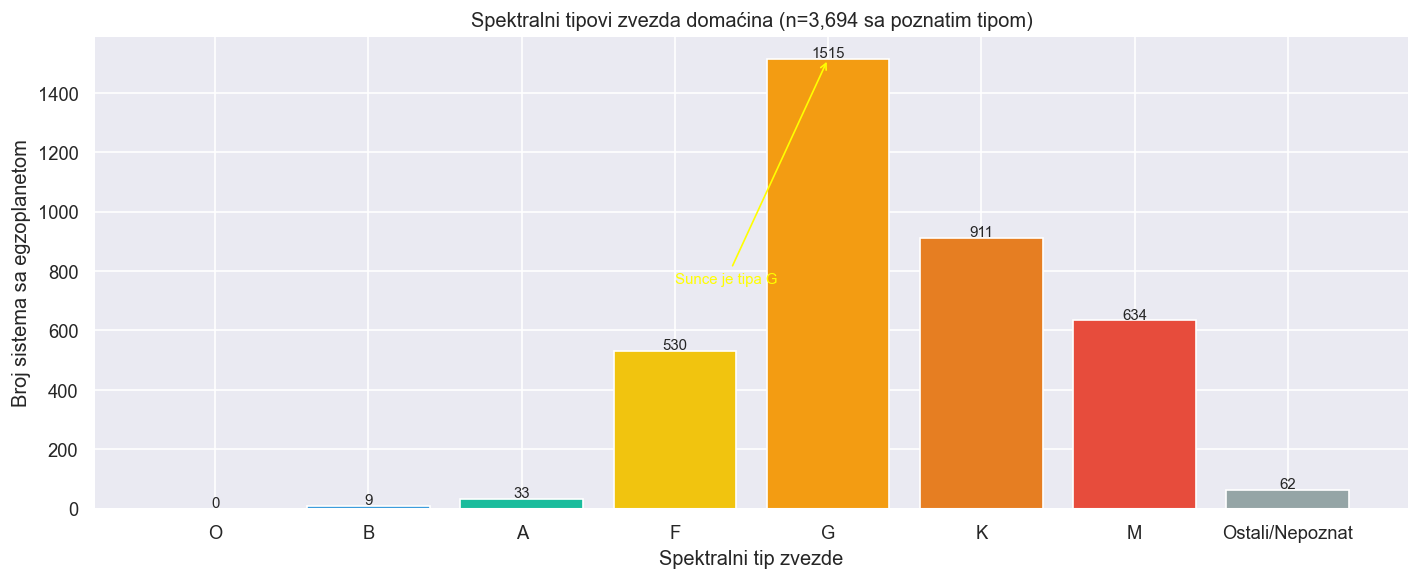

In [17]:
# Spektralni tipovi zvezda domaćina
sp_raw = df["star_sp_type"].dropna()

def extract_sp_class(sp):
    sp = str(sp).strip()
    for c in ["O", "B", "A", "F", "G", "K", "M"]:
        if sp.startswith(c):
            return c
    return "Ostali/Nepoznat"

sp_class = sp_raw.apply(extract_sp_class)
sp_counts = sp_class.value_counts()

ordered = ["O", "B", "A", "F", "G", "K", "M", "Ostali/Nepoznat"]
sp_ordered = sp_counts.reindex(ordered, fill_value=0)

colors_sp = ["#9b59b6", "#3498db", "#1abc9c", "#f1c40f",
             "#f39c12", "#e67e22", "#e74c3c", "#95a5a6"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sp_ordered.index, sp_ordered.values, color=colors_sp, edgecolor="white")
for bar, val in zip(bars, sp_ordered.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", fontsize=9)
ax.set_xlabel("Spektralni tip zvezde")
ax.set_ylabel("Broj sistema sa egzoplanetom")
ax.set_title(f"Spektralni tipovi zvezda domaćina (n={len(sp_raw):,} sa poznatim tipom)")

# Anotacija za Sunce
ax.annotate("Sunce je tipa G", xy=("G", sp_ordered["G"]),
            xytext=("F", sp_ordered["G"] * 0.5),
            arrowprops=dict(arrowstyle="->", color="yellow"),
            fontsize=9, color="yellow")
plt.tight_layout()
plt.show()

---
## 9. Raspored na nebu (RA/Dec mapa) i udaljenosti

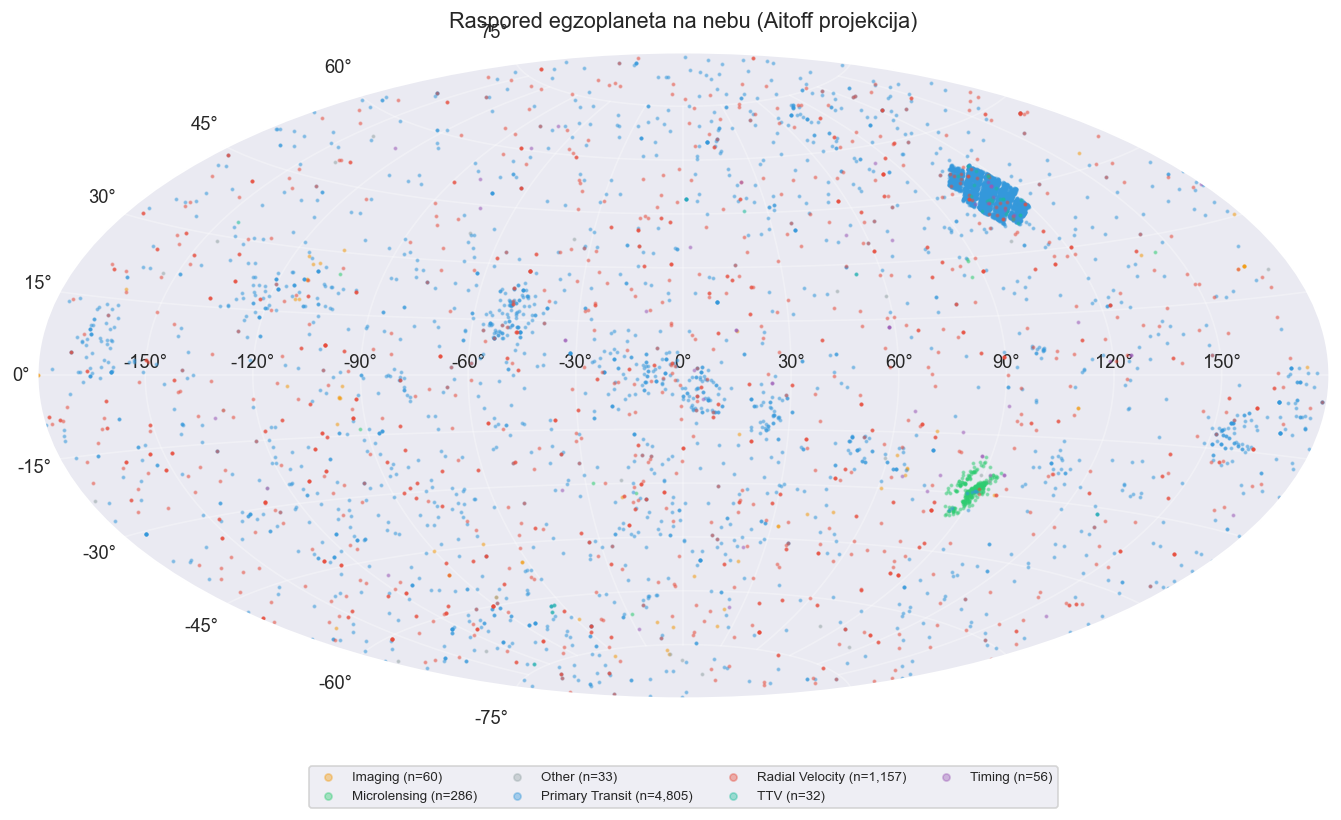

Egzoplanete sa poznatim koordinatama: 6,429 od 6,429


In [18]:
sky = df[["ra", "dec", "star_distance", "detection_type"]].dropna(subset=["ra", "dec"]).copy()
sky["det_simple"] = sky["detection_type"].apply(simplify_method)

fig = plt.figure(figsize=(16, 7))
ax = fig.add_subplot(111, projection="aitoff")

method_colors = {
    "Primary Transit": "#3498db", "Radial Velocity": "#e74c3c",
    "Microlensing": "#2ecc71", "Imaging": "#f39c12",
    "Timing": "#9b59b6", "TTV": "#1abc9c", "Other": "#95a5a6"
}

# RA u radijane (0-360 -> -pi do pi), Dec u radijane
for method, grp in sky.groupby("det_simple"):
    ra_rad = np.radians(grp["ra"].values - 180)
    dec_rad = np.radians(grp["dec"].values)
    ax.scatter(ra_rad, dec_rad, s=2, alpha=0.4,
               color=method_colors.get(method, "white"),
               label=f"{method} (n={len(grp):,})")

ax.set_title("Raspored egzoplaneta na nebu (Aitoff projekcija)", fontsize=13, pad=15)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18),
          ncol=4, fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Egzoplanete sa poznatim koordinatama: {len(sky):,} od {len(df):,}")

C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\4124225963.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_det, x="det_simple", y="star_distance", order=order,


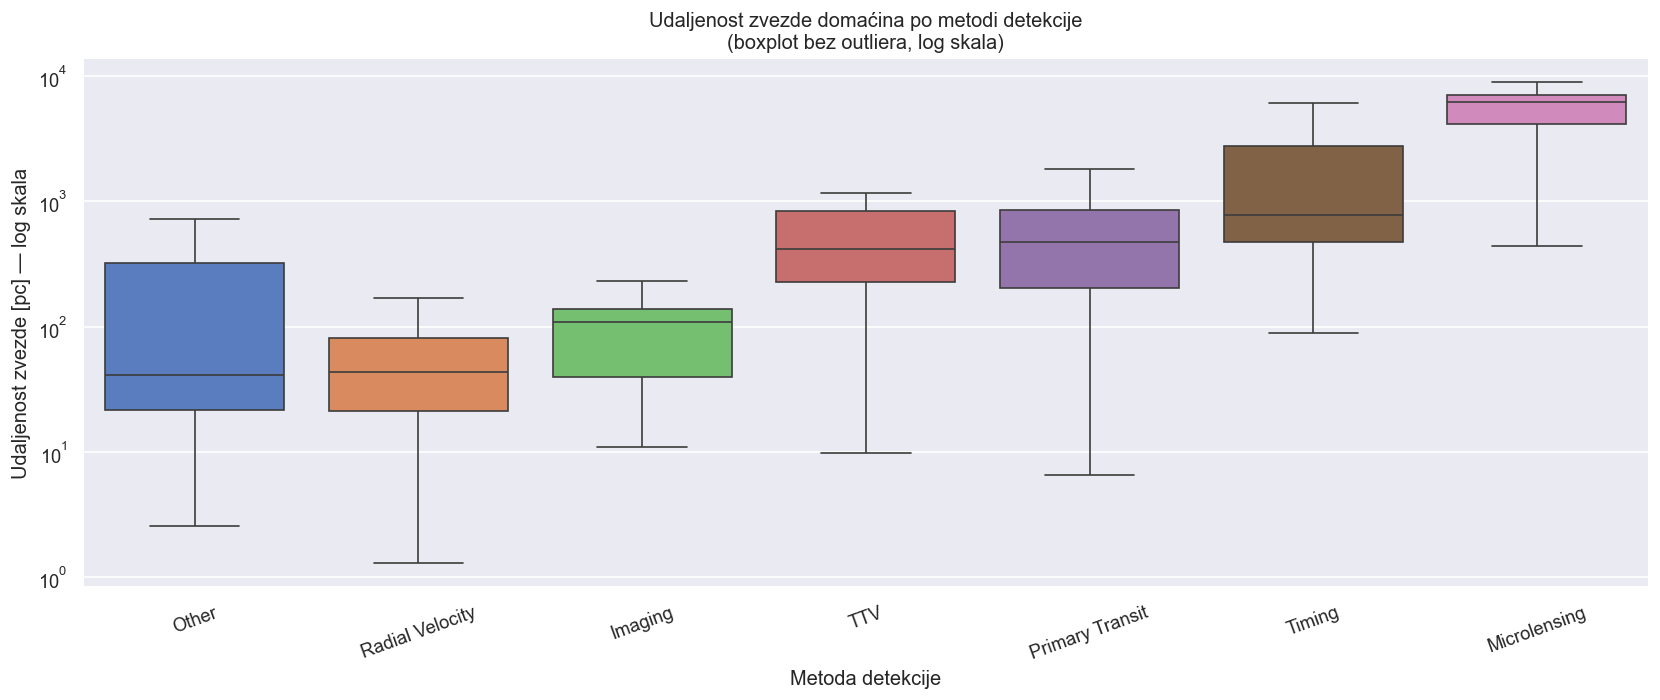


Medijana udaljenosti po metodi [pc]:
det_simple
Other                40.8
Radial Velocity      43.6
Imaging             109.6
TTV                 418.4
Primary Transit     473.2
Timing              781.7
Microlensing       6220.0


In [19]:
# Udaljenost zvezde — po metodi detekcije
dist_det = df[["star_distance", "detection_type"]].dropna().copy()
dist_det = dist_det[dist_det["star_distance"] > 0]
dist_det["det_simple"] = dist_det["detection_type"].apply(simplify_method)

fig, ax = plt.subplots(figsize=(14, 6))
order = dist_det.groupby("det_simple")["star_distance"].median().sort_values().index
sns.boxplot(data=dist_det, x="det_simple", y="star_distance", order=order,
            palette="muted", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_xlabel("Metoda detekcije")
ax.set_ylabel("Udaljenost zvezde [pc] — log skala")
ax.set_title("Udaljenost zvezde domaćina po metodi detekcije\n(boxplot bez outliera, log skala)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("\nMedijana udaljenosti po metodi [pc]:")
print(dist_det.groupby("det_simple")["star_distance"].median().sort_values().round(1).to_string())

---
## 10. Višeplanetni sistemi

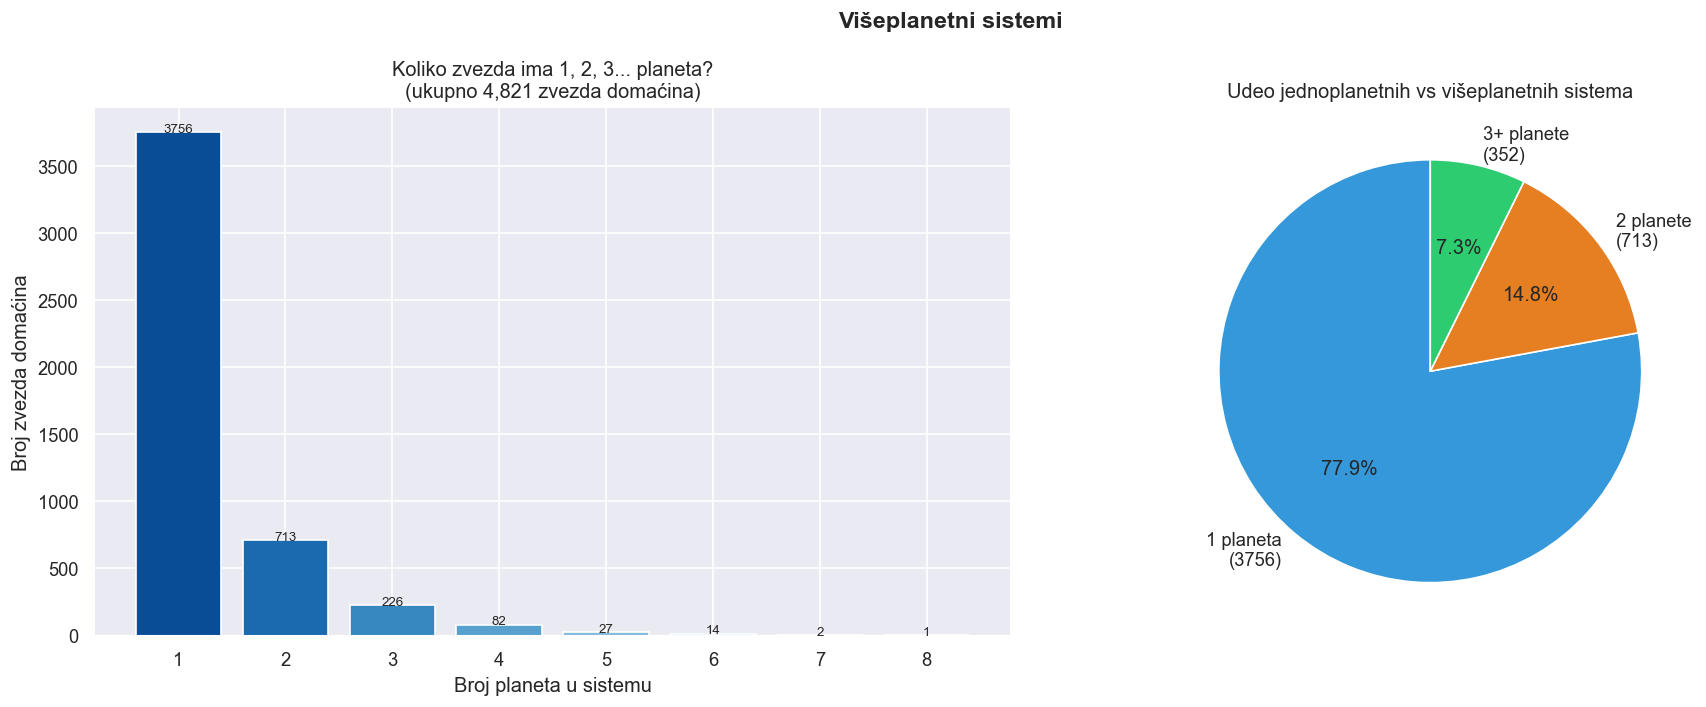


Najviše planeta u jednom sistemu: 8
Top 5 sistema sa najviše planeta:
 star_name  n_planets
 Kepler-90          8
 HD 219134          7
TRAPPIST-1          7
   L 98-59          6
  HD 40307          6


In [20]:
planets_per_star = df.groupby("star_name").size().reset_index(name="n_planets")
pp_counts = planets_per_star["n_planets"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribucija broja planeta
axes[0].bar(pp_counts.index, pp_counts.values,
            color=sns.color_palette("Blues_r", len(pp_counts)), edgecolor="white")
for x, y in zip(pp_counts.index, pp_counts.values):
    axes[0].text(x, y + 1, str(y), ha="center", fontsize=8)
axes[0].set_xlabel("Broj planeta u sistemu")
axes[0].set_ylabel("Broj zvezda domaćina")
axes[0].set_title(f"Koliko zvezda ima 1, 2, 3... planeta?\n(ukupno {len(planets_per_star):,} zvezda domaćina)")

# Pie — sistemi sa 1 vs 2 vs 3+ planeta
single = (planets_per_star["n_planets"] == 1).sum()
double = (planets_per_star["n_planets"] == 2).sum()
triple_plus = (planets_per_star["n_planets"] >= 3).sum()
axes[1].pie([single, double, triple_plus],
            labels=[f"1 planeta\n({single})", f"2 planete\n({double})", f"3+ planete\n({triple_plus})"],
            autopct="%1.1f%%", colors=["#3498db", "#e67e22", "#2ecc71"],
            startangle=90)
axes[1].set_title("Udeo jednoplanetnih vs višeplanetnih sistema")

plt.suptitle("Višeplanetni sistemi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nNajviše planeta u jednom sistemu: {planets_per_star['n_planets'].max()}")
top5 = planets_per_star.sort_values("n_planets", ascending=False).head(5)
print("Top 5 sistema sa najviše planeta:")
print(top5.to_string(index=False))

---
## 11. Korelaciona matrica ključnih promenljivih

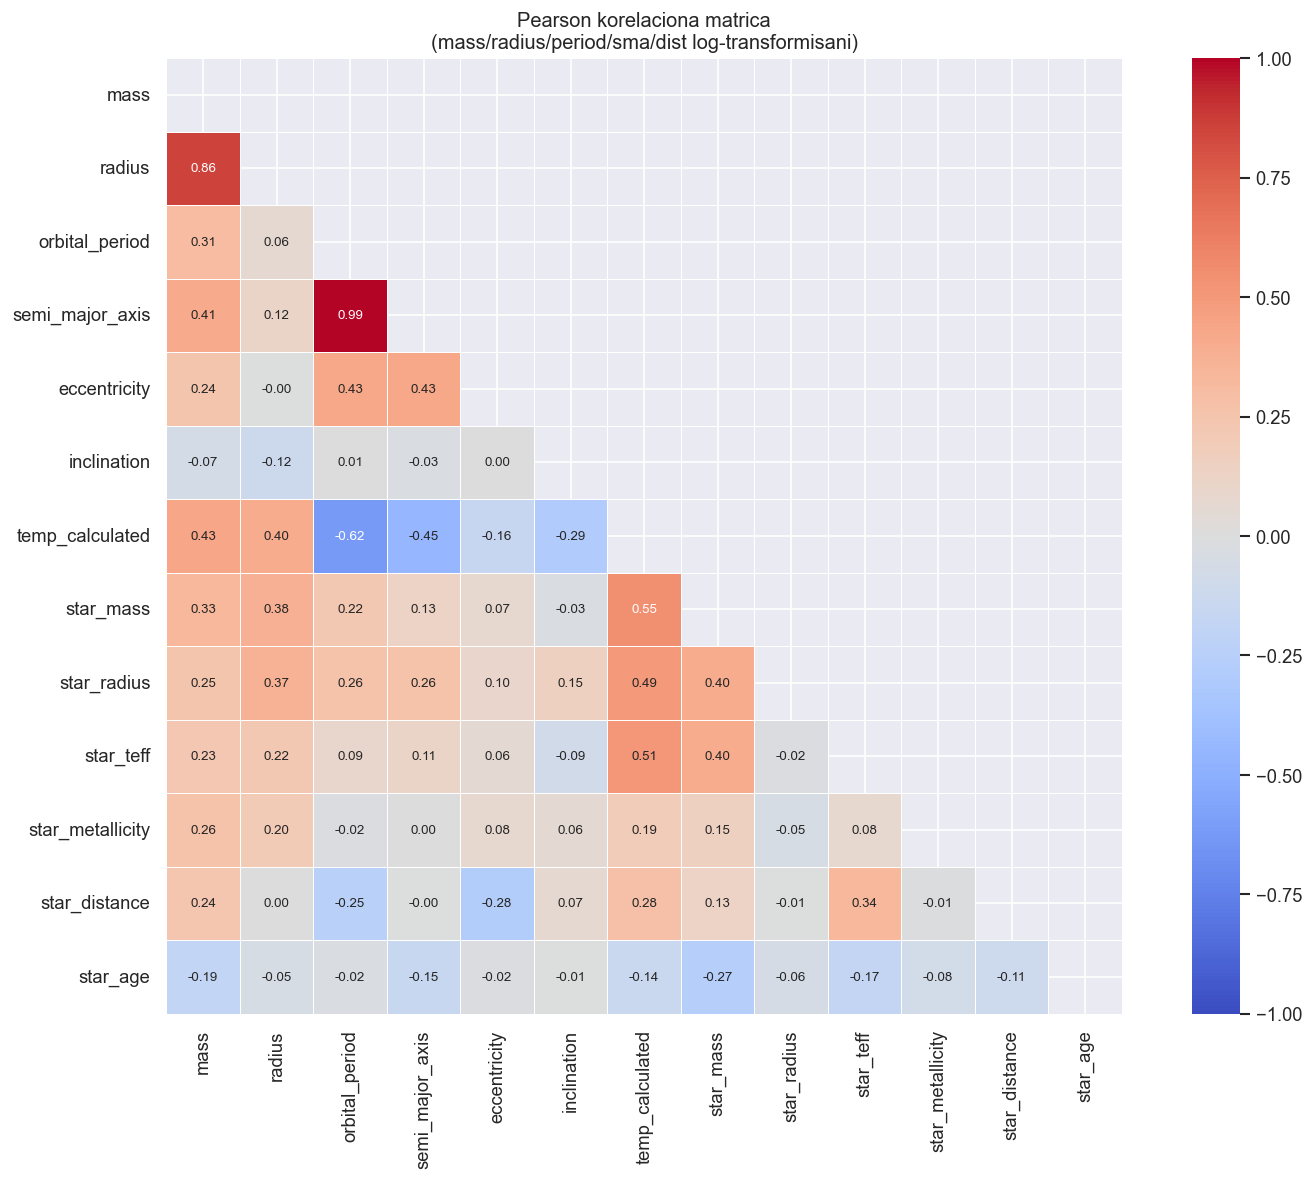

In [21]:
corr_cols = ["mass", "radius", "orbital_period", "semi_major_axis",
             "eccentricity", "inclination", "temp_calculated",
             "star_mass", "star_radius", "star_teff",
             "star_metallicity", "star_distance", "star_age"]

corr_df = df[corr_cols].copy()
# Log transform za skewed kolone
for c in ["mass", "radius", "orbital_period", "semi_major_axis", "star_distance"]:
    corr_df[c] = np.log10(corr_df[c].clip(lower=1e-10))

corr_matrix = corr_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Pearson korelaciona matrica\n(mass/radius/period/sma/dist log-transformisani)",
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. Klasifikacija planeta po tipu (Zemlja / Super-Zemlja / Neptun / Jupiter)

planet_class
Super-Zemlja (2-4R⊕)    1844
Zemlja (R<2R⊕)          1744
Nepoznat                1525
Jupiter-klasa            983
Mini-Neptun (4-6R⊕)      226
Neptun-klasa             107

Nepoznat radijus: 1,525 (23.7%)


C:\Users\Dell\AppData\Local\Temp\ipykernel_3188\2740940207.py:50: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


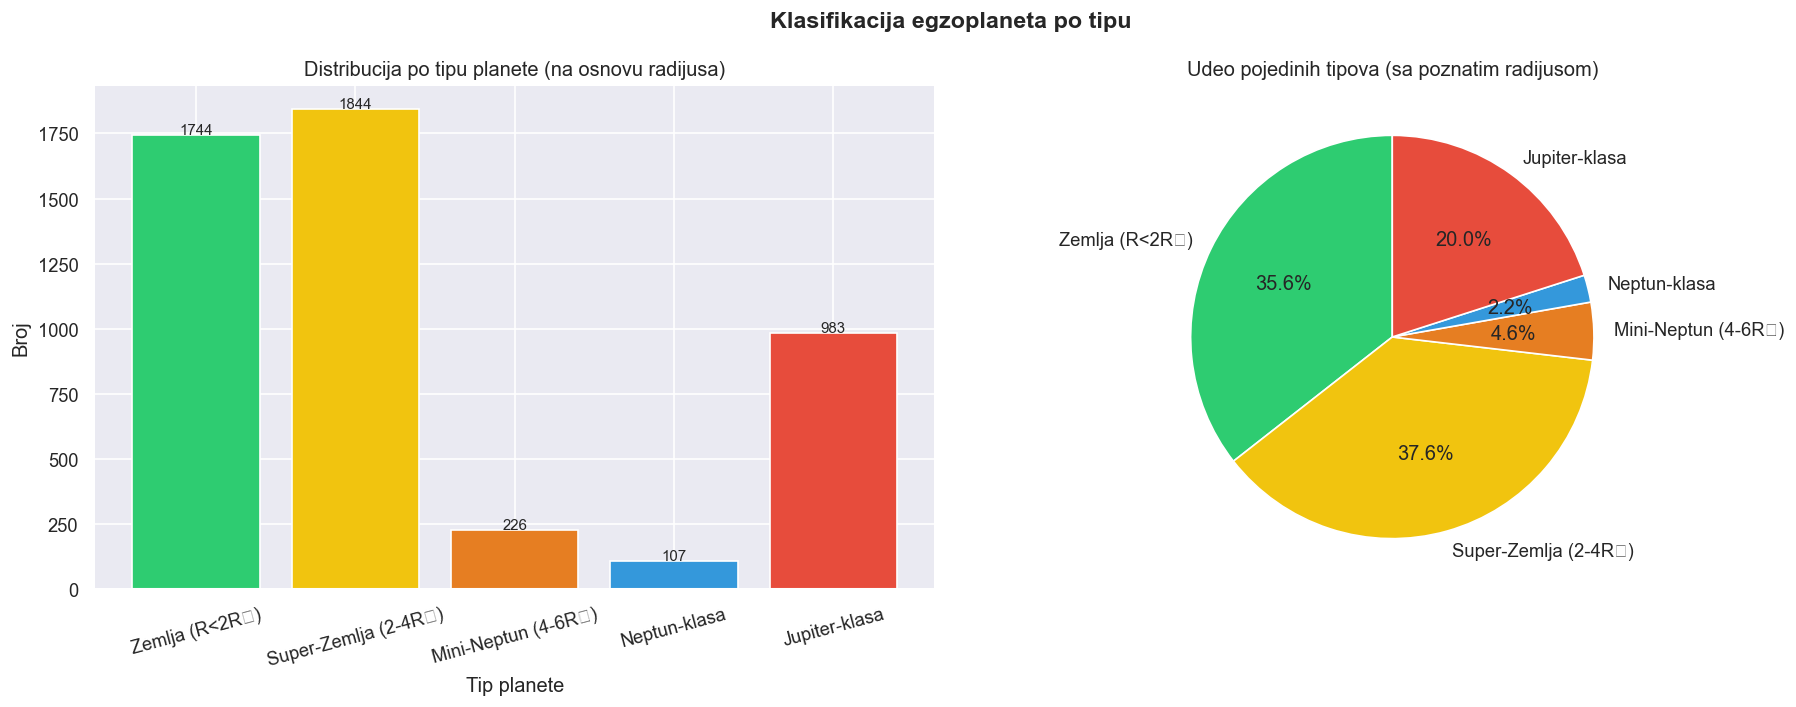

In [22]:
# Klasifikacija po radijusu (u Jupiter radijusima)
# 1 Rj = 11.2 R⊕  =>  1 R⊕ ≈ 0.0892 Rj
# Zemlja:        R < 0.18 Rj  (~2 R⊕)
# Super-Zemlja:  0.18 <= R < 0.36 Rj  (~2-4 R⊕)
# Mini-Neptun:   0.36 <= R < 0.54 Rj  (~4-6 R⊕)
# Neptun-klasa:  0.54 <= R < 0.7 Rj
# Jupiter-klasa: R >= 0.7 Rj

def classify_planet(r):
    if pd.isna(r):
        return "Nepoznat"
    if r < 0.18:
        return "Zemlja (R<2R⊕)"
    elif r < 0.36:
        return "Super-Zemlja (2-4R⊕)"
    elif r < 0.54:
        return "Mini-Neptun (4-6R⊕)"
    elif r < 0.70:
        return "Neptun-klasa"
    else:
        return "Jupiter-klasa"

df["planet_class"] = df["radius"].apply(classify_planet)
class_counts = df["planet_class"].value_counts()
print(class_counts.to_string())
print(f"\nNepoznat radijus: {(df['planet_class']=='Nepoznat').sum():,} ({(df['planet_class']=='Nepoznat').mean()*100:.1f}%)")

# Bar chart
known = class_counts.drop("Nepoznat", errors="ignore")
order_cls = ["Zemlja (R<2R⊕)", "Super-Zemlja (2-4R⊕)", "Mini-Neptun (4-6R⊕)",
             "Neptun-klasa", "Jupiter-klasa"]
known = known.reindex([c for c in order_cls if c in known.index])
cls_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#3498db", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bars = axes[0].bar(known.index, known.values, color=cls_colors, edgecolor="white")
for bar, val in zip(bars, known.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", fontsize=9)
axes[0].set_xlabel("Tip planete")
axes[0].set_ylabel("Broj")
axes[0].set_title("Distribucija po tipu planete (na osnovu radijusa)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(known.values, labels=known.index, autopct="%1.1f%%",
            colors=cls_colors, startangle=90)
axes[1].set_title("Udeo pojedinih tipova (sa poznatim radijusom)")

plt.suptitle("Klasifikacija egzoplaneta po tipu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 13. Outlieri i extremne vrednosti

In [23]:
print("=== Ekstremi u datasetu ===\n")

cols_extremes = {
    "mass":           ("Masa [Mj]", "max"),
    "radius":         ("Radijus [Rj]", "max"),
    "orbital_period": ("Orb. period [dani]", "max"),
    "semi_major_axis":("Vel. poluosa [AU]", "max"),
    "eccentricity":   ("Ekscentricitet", "max"),
    "temp_calculated":("Temp. [K]", "max"),
    "star_distance":  ("Udaljenost [pc]", "max"),
    "star_age":       ("Starost zvezde [Gyr]", "max"),
}

for col, (label, func) in cols_extremes.items():
    sub = df[["name", col]].dropna()
    if func == "max":
        row = sub.loc[sub[col].idxmax()]
        print(f"{label:30s}: {row[col]:.4g}  →  {row['name']}")

print()
# Najmanji radijus i masa
for col, label in [("radius","Najmanji radijus [Rj]"), ("mass","Najmanja masa [Mj]")]:
    sub = df[["name", col]].dropna()
    sub = sub[sub[col] > 0]
    row = sub.loc[sub[col].idxmin()]
    print(f"{label:30s}: {row[col]:.5g}  →  {row['name']}")

print()
print("=== Planete sa visokim ekscentricitetom (e > 0.8) ===")
high_ecc = df[df["eccentricity"] > 0.8][["name", "eccentricity", "orbital_period", "detection_type"]].sort_values("eccentricity", ascending=False)
print(high_ecc.head(10).to_string(index=False))
print(f"Ukupno sa e>0.8: {len(high_ecc)}")

=== Ekstremi u datasetu ===

Masa [Mj]                     : 12.93  →  GJ 2030 Ac
Radijus [Rj]                  : 6.9  →  HD 100546 b
Orb. period [dani]            : 2.723e+06  →  DH Tau b
Vel. poluosa [AU]             : 8.068e+04  →  KPNO-Tau 12
Ekscentricitet                : 3.155  →  ISO 2I
Temp. [K]                     : 3921  →  KELT-9 Ab
Udaljenost [pc]               : 8900  →  KMT-2021-BLG-0736 b
Starost zvezde [Gyr]          : 15  →  WASP-29 Ab

Najmanji radijus [Rj]         : 2e-06  →  ISO 1I
Najmanja masa [Mj]            : 0.00019  →  LHS 1678 b

=== Planete sa visokim ekscentricitetom (e > 0.8) ===
            name  eccentricity  orbital_period  detection_type
          ISO 2I       3.15500             NaN         Imaging
          ISO 1I       1.19600             NaN         Imaging
      HD 20782 b       0.97000      591.900000 Radial Velocity
TIC 241249530 Ab       0.94120      165.771900 Primary Transit
      HD 80606 b       0.93183      111.436765 Radial Velocity
   K

---
## 14. Sažetak i ključni zaključci

In [25]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              SAŽETAK EDA — exoplanet.eu katalog                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset:                                                            ║
║  • 6 429 potvrđenih egzoplaneta, 98 kolona                           ║
║  • Sve planete imaju status "Confirmed" — nema ciljne promenljive    ║
║    koja bi direktno delila klase (binarno), što znači da ML zadatak  ║
║    treba definisati (npr. tip planete, habitabilnost, metoda det.)   ║
║                                                                      ║
║  Nedostajuće vrednosti:                                              ║
║  • ~50 kolona ima >50% NaN-ova                                       ║
║  • Samo name, planet_status, detection_type nemaju NaN               ║
║  • Masa poznata za ~44%, radijus za ~79%, oboje za ~34%              ║
║  • Temp, albedo, log_g, molekuli — gotovo potpuno prazni             ║
║                                                                      ║
║  Detekcija:                                                          ║
║  • Primary Transit: 74.4% (Kepler/TESS dominiraju)                  ║
║  • Radial Velocity: 16.6% (starija metoda, bliske zvezde)            ║
║  • Microlensing: 4.5% (veće udaljenosti, bez orbit. podataka)       ║
║                                                                      ║
║  Otkrivanje kroz vreme:                                              ║
║  • Pre 2009. < 400 planeta; Kepler je eksplodirao katalog            ║
║  • Vrhunac: 2016. (rekordna godina po otkrićima)                     ║
║  • TESS nastavlja rast od 2019.                                      ║
║                                                                      ║
║  Fizičke osobine:                                                    ║
║  • Masa: ekstremno desno-asimetrična; most planeta < 1 Mj            ║
║  • Radijus: 2 moda — "Super-Zemlja" (~1.5 R⊕) i "Jupiter" (~1 Rj)  ║
║  • Ekscentricitet: ~60% planeta ima e < 0.1 (skoro kružne orbite)   ║
║  • Period: pik oko 1-10 dana (tranzitni bias) + repovi do god/vek   ║
║  • Hot Jupiters (P<10d, M>0.3Mj): ~2-3% kataloga                   ║
║                                                                      ║
║  Zvezde domaćini:                                                    ║
║  • Dominiraju G i K tip (sunčolike i malo hladnije)                  ║
║  • ~56% zvezda je metaličnije od Sunca ([Fe/H]>0) — potvrđuje       ║
║    korelaciju metalnosti i formiranja planeta                        ║
║  • Medijana udaljenosti: RV metoda ~50pc, tranzit ~400pc,           ║
║    microlensing ~2000pc — bias u detektabilnosti                     ║
║                                                                      ║
║  Višeplanetni sistemi:                                               ║
║  • ~70% zvezda ima samo 1 potvrđenu planetu u bazi                   ║
║  • Sistemi sa 5+ planeta: retki ali poznati                         ║
║                                                                      ║
║  Za preprocessing:                                                   ║
║  • Razmisliti o log-transformaciji: mass, radius, period, sma, dist  ║
║  • Dropovati kolone sa >80% NaN (timing, albedo, molecules...)       ║
║  • mass_sini je alternativa za masu (RV metoda ne daje pravu masu)  ║
║  • Imputacija: zvezda. osobine se mogu popuniti iz sp_type + teff    ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              SAŽETAK EDA — exoplanet.eu katalog                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset:                                                            ║
║  • 6 429 potvrđenih egzoplaneta, 98 kolona                           ║
║  • Sve planete imaju status "Confirmed" — nema ciljne promenljive    ║
║    koja bi direktno delila klase (binarno), što znači da ML zadatak  ║
║    treba definisati (npr. tip planete, habitabilnost, metoda det.)   ║
║                                                                      ║
║  Nedostajuće vrednosti:                                              ║
║  • ~50 kolona ima >50% NaN-ova                                       ║
║  • Samo name, planet_status, detection_type nemaju NaN               ║
║  • Masa poznata za ~44%, radijus za ~79%, oboje za ~34%              ║
║  • Temp, albedo, log_g, molekuli — gotovo potpuno